# Install and import

In [1]:
!pip install torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.9 MB/s eta 0:00:00


In [2]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.6 MB/s eta 0:00:00


In [ ]:
!wc -l /content/UNSW-NB15_1.csv

700001 /content/UNSW-NB15_1.csv


In [3]:
import pandas as pd
import numpy as np

from datetime import timedelta

import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATv2Conv
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve


import umap.umap_ as umap

import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

from torch.optim.lr_scheduler import ReduceLROnPlateau


# Data - 5elem

## UNSW1

In [4]:
data_unsw1 = pd.read_csv('/content/UNSW-NB15_1.csv', dtype={'sport': object, 'dsport': object}, low_memory=False)

columnas = [
    "srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl",
    "dttl", "sloss", "dloss", "service", "sload", "dload", "spkts", "dpkts", "swin", "dwin",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len", "sjit", "djit",
    "stime", "ltime", "sintpkt", "dintpkt", "tcprtt", "synack", "ackdat", "is_sm_ips_ports",
    "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src", "ct_srv_dst",
    "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "attack_cat", "label"
]

data_unsw1.columns = columnas


# Convert 'stime' and 'ltime' to datetime format
data_unsw1['stime'] = pd.to_datetime(data_unsw1['stime'], unit='s')
data_unsw1['ltime'] = pd.to_datetime(data_unsw1['ltime'], unit='s')


# Filter connections lasting less than a second
filtered_unsw1 = data_unsw1[(data_unsw1['dur']>0) & (data_unsw1['dur'] <= 1)]


# # Filter connections from the first 110 minutes (that's where there are malicios connections)
# # And select columns of interest
# start_time = data_unsw1['stime'].min()
# end_time = start_time + timedelta(minutes=110)

# unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']].drop_duplicates()

# # Drop rows with NaN values (i.e., missing ports)
# unsw1_sub.replace('-', pd.NA, inplace=True)
# unsw1 = unsw1_sub.dropna()

### Option 3 (more features) for RNN - 172471 nodes

Here all snapshots should have the same indices for all nodes: if node 1 is present in snapshot 1 and 5, then it should have the same index in both snapshots.

In [5]:
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','sttl','dttl','sloss','dloss','sload','dload','spkts','dpkts','sjit','djit','stime','ltime','sintpkt','dintpkt','synack','ackdat','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

In [6]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


src = unsw1[['srcip', 'sport','proto']].copy()
src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

dst = unsw1[['dstip', 'dsport','proto']].copy()
dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

unique_pairs = pd.concat([src,dst]).drop_duplicates()
unique_pairs['ip'] = unique_pairs['ip'].str.strip()
unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    # src = snapshot_data[['srcip', 'sport','proto']].copy()
    # src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    # dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    # dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    # unique_pairs = pd.concat([src,dst]).drop_duplicates()
    # unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    # unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    # unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    # unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    # unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    # unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    # pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean',
        'sttl': 'mean',
        'sloss': 'mean',
        'sload': 'mean',
        'sjit': 'mean',
        'sintpkt': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean',
        'dttl': 'mean',
        'dloss': 'mean',
        'dload': 'mean',
        'djit': 'mean',
        'dintpkt': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt', 'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'synack': 'mean',
        'ackdat': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto_more_rnn = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [7]:
torch_geo_graphs_unsw1_proto_more_rnn

{0: Data(x=[172471, 14], edge_index=[2, 3279], edge_attr=[3279, 3], y=[3279]),
 1: Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
 2: Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
 3: Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
 4: Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
 5: Data(x=[172471, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554]),
 6: Data(x=[172471, 14], edge_index=[2, 3971], edge_attr=[3971, 3], y=[3971]),
 7: Data(x=[172471, 14], edge_index=[2, 3605], edge_attr=[3605, 3], y=[3605]),
 8: Data(x=[172471, 14], edge_index=[2, 3414], edge_attr=[3414, 3], y=[3414]),
 9: Data(x=[172471, 14], edge_index=[2, 3300], edge_attr=[3300, 3], y=[3300]),
 10: Data(x=[172471, 14], edge_index=[2, 3333], edge_attr=[3333, 3], y=[3333]),
 11: Data(x=[172471, 14], edge_index=[2, 3379], edge_attr=[3379, 3], y=[3379]),
 12: Data(x=[172471, 14], edge_index=[2, 3664], ed

## UNSW2

In [8]:
data_unsw2 = pd.read_csv('/content/UNSW-NB15_2.csv', dtype={'sport': object, 'dsport': object}, low_memory=False)

columnas = [
    "srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl",
    "dttl", "sloss", "dloss", "service", "sload", "dload", "spkts", "dpkts", "swin", "dwin",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len", "sjit", "djit",
    "stime", "ltime", "sintpkt", "dintpkt", "tcprtt", "synack", "ackdat", "is_sm_ips_ports",
    "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src", "ct_srv_dst",
    "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "attack_cat", "label"
]

data_unsw2.columns = columnas


# Convert 'stime' and 'ltime' to datetime format
data_unsw2['stime'] = pd.to_datetime(data_unsw2['stime'], unit='s')
data_unsw2['ltime'] = pd.to_datetime(data_unsw2['ltime'], unit='s')


# Filter connections lasting less than a second
filtered_unsw2 = data_unsw2[(data_unsw2['dur']>0) & (data_unsw2['dur'] <= 1)]



In [9]:
start_time = data_unsw2['stime'].min() + timedelta(minutes=628*60)
end_time = start_time + timedelta(minutes=4*60)

unsw2_sub = filtered_unsw2[(filtered_unsw2['stime'] >= start_time) & (filtered_unsw2['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','sttl','dttl','sloss','dloss','sload','dload','spkts','dpkts','sjit','djit','stime','ltime','sintpkt','dintpkt','synack','ackdat','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw2_sub.replace('-', pd.NA, inplace=True)
unsw2 = unsw2_sub.dropna()



In [10]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw2['stime'].min()
max_end_time = unsw2['ltime'].max()


interval_snapshot = timedelta(minutes=30)
start_time = min_start_time
end_time = start_time  + interval_snapshot


src = unsw2[['srcip', 'sport','proto']].copy()
src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

dst = unsw2[['dstip', 'dsport','proto']].copy()
dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

unique_pairs = pd.concat([src,dst]).drop_duplicates()
unique_pairs['ip'] = unique_pairs['ip'].str.strip()
unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}


while start_time  < max_end_time:
    snapshot_data = unsw2[(unsw2['stime'] >= start_time ) & (unsw2['stime'] < end_time)]

    # src = snapshot_data[['srcip', 'sport','proto']].copy()
    # src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    # dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    # dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    # unique_pairs = pd.concat([src,dst]).drop_duplicates()
    # unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    # unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    # unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    # unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    # unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    # unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    # pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean',
        'sttl': 'mean',
        'sloss': 'mean',
        'sload': 'mean',
        'sjit': 'mean',
        'sintpkt': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean',
        'dttl': 'mean',
        'dloss': 'mean',
        'dload': 'mean',
        'djit': 'mean',
        'dintpkt': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt', 'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'synack': 'mean',
        'ackdat': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw2_proto_more_rnn = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [11]:
torch_geo_graphs_unsw2_proto_more_rnn

{0: Data(x=[262986, 14], edge_index=[2, 13377], edge_attr=[13377, 3], y=[13377]),
 1: Data(x=[262986, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
 2: Data(x=[262986, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
 3: Data(x=[262986, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695]),
 4: Data(x=[262986, 14], edge_index=[2, 35200], edge_attr=[35200, 3], y=[35200]),
 5: Data(x=[262986, 14], edge_index=[2, 38685], edge_attr=[38685, 3], y=[38685])}

In [12]:
for i in range(len(torch_geo_graphs_unsw2_proto_more_rnn)):
  suma_1 = 0
  suma_0 = 0
  for j in range(len(torch_geo_graphs_unsw2_proto_more_rnn[i].y)):
    if torch_geo_graphs_unsw2_proto_more_rnn[i].y[j]==1:
      suma_1+=1
    if torch_geo_graphs_unsw2_proto_more_rnn[i].y[j]==0:
      suma_0+=1
  if not suma_1==0:
    print(i,suma_0,suma_1,suma_0/suma_1)
  else:
    print(i,suma_0,suma_1)

0 12827 550 23.32181818181818
1 18693 1049 17.819828408007627
2 34489 1741 19.809879379666857
3 32965 1730 19.05491329479769
4 33573 1627 20.634910878918255
5 36758 1927 19.075246497145823


## Generate sliding windows

In [13]:
def generate_sliding_windows(graph_snapshots, num_snapshots_train, window_size, generate_val=False):

    windows_input_train= []

    for t in range(num_snapshots_train - window_size + 1):
        window = []
        for t_key in range(t, t + window_size):
            window.append(graph_snapshots[t_key])
        windows_input_train.append(window)

    if generate_val:
        windows_input_val= []
        num_snapshots_val = len(graph_snapshots) - num_snapshots_train

        for t in range(num_snapshots_val - window_size +1 ):
            window = []
            for t_key in range(num_snapshots_train + t, num_snapshots_train + t + window_size):
                window.append(graph_snapshots[t_key])
            windows_input_val.append(window)

        return windows_input_train, windows_input_val

    else:
        return windows_input_train



In [14]:
windows_input_train, windows_input_val = generate_sliding_windows(torch_geo_graphs_unsw1_proto_more_rnn, 28, 4, True)

In [ ]:
windows_input_train

[[Data(x=[172471, 14], edge_index=[2, 3279], edge_attr=[3279, 3], y=[3279]),
  Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
  Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
  Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187])],
 [Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
  Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
  Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
  Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376])],
 [Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
  Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
  Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
  Data(x=[172471, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554])],
 [Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187

In [ ]:
windows_input_val

[[Data(x=[172471, 14], edge_index=[2, 3361], edge_attr=[3361, 3], y=[3361]),
  Data(x=[172471, 14], edge_index=[2, 3408], edge_attr=[3408, 3], y=[3408]),
  Data(x=[172471, 14], edge_index=[2, 3553], edge_attr=[3553, 3], y=[3553]),
  Data(x=[172471, 14], edge_index=[2, 3890], edge_attr=[3890, 3], y=[3890])],
 [Data(x=[172471, 14], edge_index=[2, 3408], edge_attr=[3408, 3], y=[3408]),
  Data(x=[172471, 14], edge_index=[2, 3553], edge_attr=[3553, 3], y=[3553]),
  Data(x=[172471, 14], edge_index=[2, 3890], edge_attr=[3890, 3], y=[3890]),
  Data(x=[172471, 14], edge_index=[2, 3391], edge_attr=[3391, 3], y=[3391])],
 [Data(x=[172471, 14], edge_index=[2, 3553], edge_attr=[3553, 3], y=[3553]),
  Data(x=[172471, 14], edge_index=[2, 3890], edge_attr=[3890, 3], y=[3890]),
  Data(x=[172471, 14], edge_index=[2, 3391], edge_attr=[3391, 3], y=[3391]),
  Data(x=[172471, 14], edge_index=[2, 3491], edge_attr=[3491, 3], y=[3491])],
 [Data(x=[172471, 14], edge_index=[2, 3890], edge_attr=[3890, 3], y=[3890

In [15]:
windows_input_test = generate_sliding_windows(torch_geo_graphs_unsw2_proto_more_rnn, 6, 4, False)

In [16]:
windows_input_test

[[Data(x=[262986, 14], edge_index=[2, 13377], edge_attr=[13377, 3], y=[13377]),
  Data(x=[262986, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
  Data(x=[262986, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
  Data(x=[262986, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695])],
 [Data(x=[262986, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
  Data(x=[262986, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
  Data(x=[262986, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695]),
  Data(x=[262986, 14], edge_index=[2, 35200], edge_attr=[35200, 3], y=[35200])],
 [Data(x=[262986, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
  Data(x=[262986, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695]),
  Data(x=[262986, 14], edge_index=[2, 35200], edge_attr=[35200, 3], y=[35200]),
  Data(x=[262986, 14], edge_index=[2, 38685], edge_attr=[38685, 3], y=[38685])]]

# Models

## GNN traditional - Normalize features

In [17]:
class GNN_traditional_normalize(torch.nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2):
        super(GNN_traditional_normalize, self).__init__()
        self.conv1 = SAGEConv(node_input_dim, hidden_dim1)
        self.conv2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.conv1 = GCNConv(node_input_dim, hidden_dim1)
        #self.conv2 = GCNConv(hidden_dim1, hidden_dim2)

        self.fc = torch.nn.Linear(hidden_dim2 * 2 + edge_input_dim, 1)  # Combine both nodes + edge_attr

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        #print(f"input:{x.shape}")
          # x is shape (num_nodes_in_snapshot, node_input_dim)

        # Normalization nodes features
        max_values_node = x.max(dim=0).values
        normalized_nodes_features = x / max_values_node

        # Normalization edges features
        max_values_edge = edge_attr.max(dim=0).values
        normalized_edges_features = edge_attr / max_values_edge

        x = self.conv1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
        #print(f"x after first gnn:{x.shape}")
        x = self.conv2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)
        #print(f"x after seconf gnn:{x.shape}")

        # Combine node representations with edge features
        src_nodes = edge_index[0]  # Source nodes of edges
        dst_nodes = edge_index[1]  # Destination nodes of edges

        edge_features = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges_in_snapshot, 2*hidden_dim2 + edge_input_dim)
        #print(f"edge_features:{edge_features.shape}")

        predictions = self.fc(edge_features)
        #print(f"predictions:{predictions.shape}")

        return predictions, edge_features





## GNN + RNN

In [18]:
class EdgeClassificationModel_RNN(nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2, hidden_size_gru, seq_len):
        super(EdgeClassificationModel_RNN, self).__init__()
        self.gnn1 = SAGEConv(node_input_dim, hidden_dim1)
        self.gnn2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.dropout = nn.Dropout(0.5)

        # GRU para manejar la secuencia temporal
        self.gru = nn.GRU(2 * hidden_dim2 + edge_input_dim, hidden_size_gru, batch_first=True)

        # Clasificación final (para cada arista)
        self.edge_predictor = nn.Linear(hidden_size_gru, 1)


    def forward(self, snapshots):
        """
        snapshots:
        """

        max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        # Procesar snapshots con la GNN
        edge_embeddings_seq = []
        for t in range(len(snapshots)):
            x, edge_index, edge_attr = snapshots[t].x, snapshots[t].edge_index, snapshots[t].edge_attr
              # x is shape (num_nodes_in_snapshot, node_input_dim)

            # Normalization nodes features
            max_values_node = x.max(dim=0).values
            normalized_nodes_features = x / max_values_node

            # Normalization edges features
            max_values_edge = edge_attr.max(dim=0).values
            normalized_edges_features = edge_attr / max_values_edge

            num_edges = edge_index.shape[1]

            x = self.gnn1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
            #x = self.dropout(F.relu(self.gnn1(x, edge_index)))
            x = self.gnn2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges, 2*hidden_dim2 + edge_input_dim)

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*hidden_dim2 + edge_input_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*hidden_dim2 + edge_input_dim)

            edge_embeddings_seq.append(padded_edge_embeddings)


        # Apilar resultados de GNN a lo largo del tiempo
        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1)  # (max_num_edges, seq_len, 2*hidden_dim2 + edge_input_dim)
                                                     # Note that max_num_edges=batch_size (for gru)

        # Procesar secuencia con GRU
        gru_out, _ = self.gru(edge_embeddings_seq)  # (max_num_edges, seq_len, hidden_size_gru)

        # Predecir etiquetas de aristas en el último snapshot
        final_node_embeddings = gru_out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_size_gru)
        predictions = self.edge_predictor(final_node_embeddings) # (max_num_edges, 1)

        return predictions, final_node_embeddings



## GNN + RNN - reusing h

In [19]:
class EdgeClassificationModel_RNN_v2(nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2, hidden_size_gru):#, seq_len):
        super(EdgeClassificationModel_RNN_v2, self).__init__()
        self.gnn1 = SAGEConv(node_input_dim, hidden_dim1)
        self.gnn2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.dropout = nn.Dropout(0.5)

        # GRU para manejar la secuencia temporal
        self.gru = nn.GRU(2 * hidden_dim2 + edge_input_dim, hidden_size_gru, batch_first=True)

        # Clasificación final (para cada arista)
        self.edge_predictor = nn.Linear(hidden_size_gru, 1)


    def forward(self, snapshots, max_num_edges, h_0=None):
        """
        snapshots:
        """

        #max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        # Procesar snapshots con la GNN
        edge_embeddings_seq = []
        for t in range(len(snapshots)):
            x, edge_index, edge_attr = snapshots[t].x, snapshots[t].edge_index, snapshots[t].edge_attr
              # x is shape (num_nodes_in_snapshot, node_input_dim)

            # Normalization nodes features
            max_values_node = x.max(dim=0).values
            normalized_nodes_features = x / max_values_node

            # Normalization edges features
            max_values_edge = edge_attr.max(dim=0).values
            normalized_edges_features = edge_attr / max_values_edge

            num_edges = edge_index.shape[1]

            x = self.gnn1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
            #x = self.dropout(F.relu(self.gnn1(x, edge_index)))
            x = self.gnn2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges, 2*hidden_dim2 + edge_input_dim)

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*hidden_dim2 + edge_input_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*hidden_dim2 + edge_input_dim)

            edge_embeddings_seq.append(padded_edge_embeddings)


        # Apilar resultados de GNN a lo largo del tiempo
        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1)  # (max_num_edges, seq_len, 2*hidden_dim2 + edge_input_dim)
                                                     # Note that max_num_edges=batch_size (for gru)

        # Procesar secuencia con GRU
        gru_out, h_n = self.gru(edge_embeddings_seq, h_0)  # (max_num_edges, seq_len, hidden_size_gru)

        # Predecir etiquetas de aristas en el último snapshot
        final_node_embeddings = gru_out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_size_gru)
        predictions = self.edge_predictor(final_node_embeddings) # (max_num_edges, 1)

        return predictions, h_n, final_node_embeddings



## GNN + RNN - reusing h for training

In [20]:
class EdgeClassificationModel_RNN_v3(nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2, hidden_size_gru):#, seq_len):
        super(EdgeClassificationModel_RNN_v3, self).__init__()
        self.gnn1 = SAGEConv(node_input_dim, hidden_dim1)
        self.gnn2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.dropout = nn.Dropout(0.5)

        # GRU para manejar la secuencia temporal
        self.gru = nn.GRU(2 * hidden_dim2 + edge_input_dim, hidden_size_gru, batch_first=True)

        # Clasificación final (para cada arista)
        self.edge_predictor = nn.Linear(hidden_size_gru, 1)


    def forward(self, snapshots, max_num_edges, h_0=None):
        """
        snapshots:
        """

        #max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        # Procesar snapshots con la GNN
        edge_embeddings_seq = []
        for t in range(len(snapshots)):
            x, edge_index, edge_attr = snapshots[t].x, snapshots[t].edge_index, snapshots[t].edge_attr
              # x is shape (num_nodes_in_snapshot, node_input_dim)

            # Normalization nodes features
            max_values_node = x.max(dim=0).values
            normalized_nodes_features = x / max_values_node

            # Normalization edges features
            max_values_edge = edge_attr.max(dim=0).values
            normalized_edges_features = edge_attr / max_values_edge

            num_edges = edge_index.shape[1]

            x = self.gnn1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
            #x = self.dropout(F.relu(self.gnn1(x, edge_index)))
            x = self.gnn2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges, 2*hidden_dim2 + edge_input_dim)

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*hidden_dim2 + edge_input_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*hidden_dim2 + edge_input_dim)

            edge_embeddings_seq.append(padded_edge_embeddings)


        # Apilar resultados de GNN a lo largo del tiempo
        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1)  # (max_num_edges, seq_len, 2*hidden_dim2 + edge_input_dim)
                                                     # Note that max_num_edges=batch_size (for gru)

        # Procesar secuencia con GRU
        gru_out, h_n = self.gru(edge_embeddings_seq, h_0)  # (max_num_edges, seq_len, hidden_size_gru)

        # Predecir etiquetas de aristas en el último snapshot
        final_node_embeddings = gru_out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_size_gru)
        predictions = self.edge_predictor(final_node_embeddings) # (max_num_edges, 1)

        return predictions, h_n, final_node_embeddings



# Train and test with all snapshots

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [27]:
def precision_recall_full(y_true, y_pred):
    # Contadores
    TP = FP = FN = TN = 0

    for yt, yp in zip(y_true, y_pred):
        if yp == 1 and yt == 1:
            TP += 1  # True Positive
        elif yp == 1 and yt == 0:
            FP += 1  # False Positive
        elif yp == 0 and yt == 1:
            FN += 1  # False Negative
        elif yp == 0 and yt == 0:
            TN += 1  # True Negative

    # Precisión y recall para la clase 1
    precision_1 = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_1 = TP / (TP + FN) if (TP + FN) > 0 else 0

    # Precisión y recall para la clase 0
    precision_0 = TN / (TN + FN) if (TN + FN) > 0 else 0
    recall_0 = TN / (TN + FP) if (TN + FP) > 0 else 0

    return precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN

## Model 1_4: Traditional (more features normalized - 172471 nodes)

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1_4 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1_4.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = list(range(28))
val_windows = list(range(31,36))#28,36))


# Train
epochs = 15
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1_4.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
        optimizer.zero_grad()
        out,_ = model1_4(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1_4.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
            out,_ = model1_4(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/15, Train Loss: 0.2435, Val Loss: 0.1108, , Current LR: 0.010000, ROC-AUC: 0.954389480758649, F1:0.6613404349755881
Epoch 2/15, Train Loss: 0.0933, Val Loss: 0.0803, , Current LR: 0.010000, ROC-AUC: 0.9309390526429067, F1:0.6407239819004525
Epoch 3/15, Train Loss: 0.0767, Val Loss: 0.0704, , Current LR: 0.010000, ROC-AUC: 0.9033028972177045, F1:0.7171270718232045
Epoch 4/15, Train Loss: 0.0665, Val Loss: 0.0642, , Current LR: 0.010000, ROC-AUC: 0.8255517180466471, F1:0.657035175879397
Epoch 5/15, Train Loss: 0.0593, Val Loss: 0.0622, , Current LR: 0.010000, ROC-AUC: 0.7929237553984003, F1:0.6359322033898305
Epoch 6/15, Train Loss: 0.0566, Val Loss: 0.0624, , Current LR: 0.010000, ROC-AUC: 0.778431575591819, F1:0.6342857142857142
Epoch 7/15, Train Loss: 0.0557, Val Loss: 0.0620, , Current LR: 0.010000, ROC-AUC: 0.7798853620354634, F1:0.6389684813753582
Epoch 8/15, Train Loss: 0.0552, Val Loss: 0.0615, , Current LR: 0.010000, ROC-AUC: 0.7861532932526847, F1:0.6468085106382979
Epo

In [ ]:
# Evaluación test
model1_4.eval()
all_probabilities_m1_4_test, all_preds_m1_4_test, all_labels_m1_4_test = [], [], []

last_windows_for_test = [windows_input_test[i][-1] for i in range(len(windows_input_test))]

embeddings_test = []
with torch.no_grad():
    for window in range(len(last_windows_for_test)):
        data = last_windows_for_test[window].to(device)
        labels = last_windows_for_test[window].y
        out, emb_t = model1_4(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m1_4_test.extend(probabilities)
        all_preds_m1_4_test.extend(preds)
        all_labels_m1_4_test.extend(labels.cpu().numpy())
        embeddings_test.append(emb_t)

# Metrics
roc_auc_m1_4_test = roc_auc_score(all_labels_m1_4_test, all_preds_m1_4_test)
accuracy_m1_4_test = accuracy_score(all_labels_m1_4_test, all_preds_m1_4_test)
precision_m1_4_test = precision_score(all_labels_m1_4_test, all_preds_m1_4_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_4_test = recall_score(all_labels_m1_4_test, all_preds_m1_4_test, average='binary', zero_division=0)
f1_m1_4_test = f1_score(all_labels_m1_4_test, all_preds_m1_4_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_4_test:.4f}")
print(f"Accuracy: {accuracy_m1_4_test:.4f}")
print(f"Precision: {precision_m1_4_test:.4f}")
print(f"Recall: {recall_m1_4_test:.4f}")
print(f"F1: {f1_m1_4_test:.4f}")

# ROC-AUC: 0.8898
# Accuracy: 0.9724
# Precision: 0.6853
# Recall: 0.7984
# F1: 0.7376

ROC-AUC: 0.8906
Accuracy: 0.9724
Precision: 0.6854
Recall: 0.8000
F1: 0.7383


In [ ]:
cont=0
for i in range(len(all_preds_m1_4_test)):
  if all_preds_m1_4_test[i]==0:
    cont+=1

print(cont)

102413


In [ ]:
cont=0
for i in range(len(all_preds_m1_4_test)):
  if all_preds_m1_4_test[i]==1:
    cont+=1

print(cont)

6167


In [ ]:
def precision_recall_full(y_true, y_pred):
    # Contadores
    TP = FP = FN = TN = 0

    for yt, yp in zip(y_true, y_pred):
        if yp == 1 and yt == 1:
            TP += 1  # True Positive
        elif yp == 1 and yt == 0:
            FP += 1  # False Positive
        elif yp == 0 and yt == 1:
            FN += 1  # False Negative
        elif yp == 0 and yt == 0:
            TN += 1  # True Negative

    # Precisión y recall para la clase 1
    precision_1 = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_1 = TP / (TP + FN) if (TP + FN) > 0 else 0

    # Precisión y recall para la clase 0
    precision_0 = TN / (TN + FN) if (TN + FN) > 0 else 0
    recall_0 = TN / (TN + FP) if (TN + FP) > 0 else 0

    return precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN



precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN = precision_recall_full(all_labels_m1_4_test, all_preds_m1_4_test)

print(f"Precisión (clase 1): {precision_1:.4f}")
print(f"Recall (clase 1): {recall_1:.4f}")
print(f"Precisión (clase 0): {precision_0:.4f}")
print(f"Recall (clase 0): {recall_0:.4f}")

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")

Precisión (clase 1): 0.6854
Recall (clase 1): 0.8000
Precisión (clase 0): 0.9897
Recall (clase 0): 0.9812
TP: 4227
FP: 1940
TN: 101356
FN: 1057


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-97-3bc5d8201afd>:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


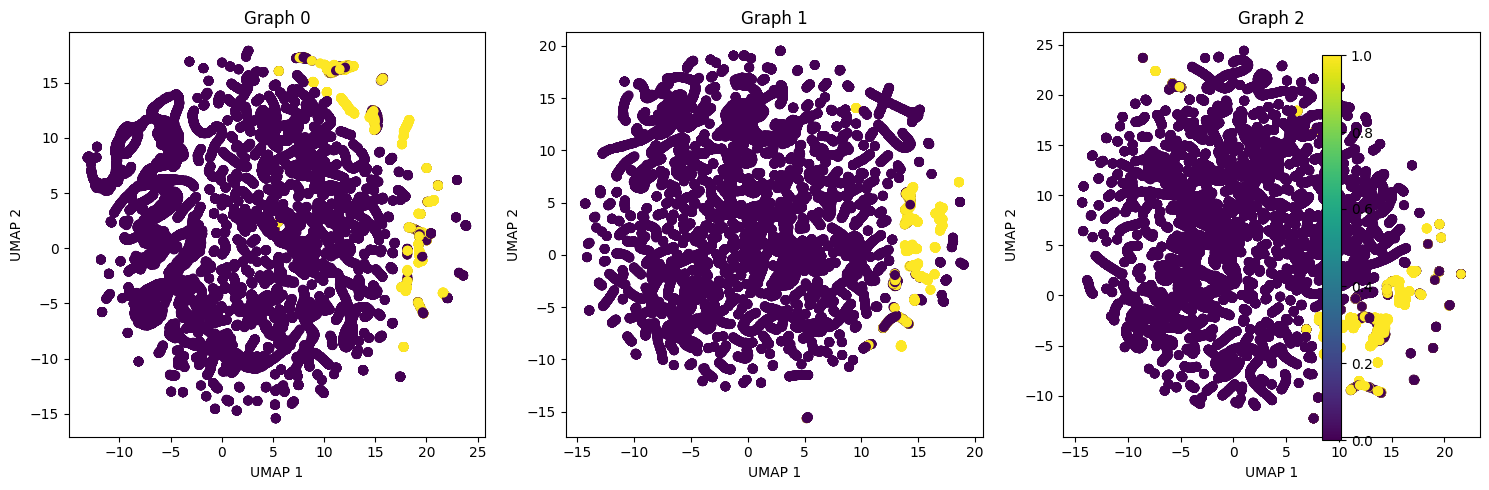

In [ ]:
num_graphs = len(last_windows_for_test)
rows, cols = 1,3

fig, axes = plt.subplots(rows, cols, figsize=(15,5))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_test[i]  # Feature embeddings
    y = last_windows_for_test[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

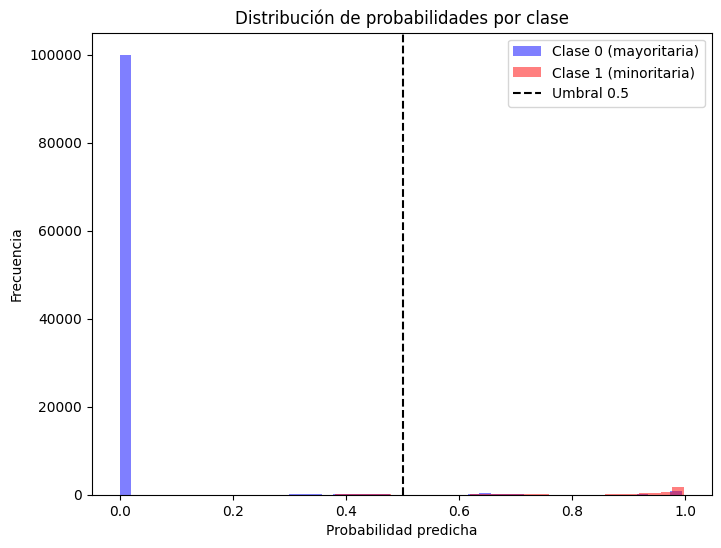

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m1_4_test)[np.array(all_labels_m1_4_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m1_4_test)[np.array(all_labels_m1_4_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

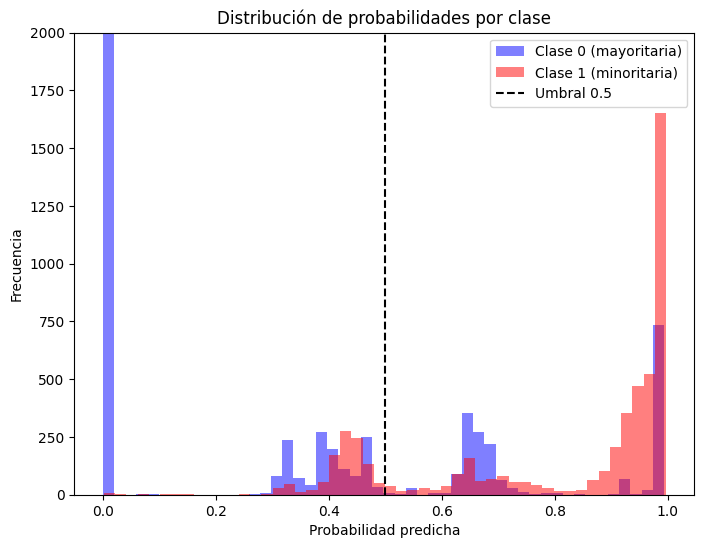

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m1_4_test)[np.array(all_labels_m1_4_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m1_4_test)[np.array(all_labels_m1_4_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,2000))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()


## GNN + RNN (more features normalized - 172471 nodes)

### Model 2_1: seq_len=4 - 25 windows for train, 5 for val

In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_1 = EdgeClassificationModel_RNN(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32, seq_len=4)
optimizer = torch.optim.Adam(model2_1.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_1.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train[window][-1].y

        optimizer.zero_grad()
        out,_ = model2_1(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    model2_1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val)):
            data_list = windows_input_val[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val[window][-1].y
            out,_ = model2_1(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2430, Val Loss: 0.0997, Current LR: 0.010000, ROC-AUC: 0.909321085791674, F1:0.6623634558093346
Epoch 2/15, Train Loss: 0.0738, Val Loss: 0.0784, Current LR: 0.010000, ROC-AUC: 0.9479855108658355, F1:0.6439493228484054
Epoch 3/15, Train Loss: 0.0696, Val Loss: 0.0751, Current LR: 0.010000, ROC-AUC: 0.9256975027766102, F1:0.6834567901234568
Epoch 4/15, Train Loss: 0.0573, Val Loss: 0.0732, Current LR: 0.010000, ROC-AUC: 0.9578249649243563, F1:0.6910606762389996
Epoch 5/15, Train Loss: 0.0564, Val Loss: 0.0750, Current LR: 0.010000, ROC-AUC: 0.9737506268946432, F1:0.6992753623188406
Epoch 6/15, Train Loss: 0.0575, Val Loss: 0.0747, Current LR: 0.010000, ROC-AUC: 0.9620391182257308, F1:0.6988847583643123
Epoch 7/15, Train Loss: 0.0552, Val Loss: 0.0739, Current LR: 0.010000, ROC-AUC: 0.9648878087011963, F1:0.7045666356011183
Epoch 8/15, Train Loss: 0.0544, Val Loss: 0.0743, Current LR: 0.010000, ROC-AUC: 0.9687100893997446, F1:0.7016091954022988
Epoch 9/15, Train

In [ ]:
# Evaluación test
model2_1.eval()
all_probabilities_m2_1_test, all_preds_m2_1_test, all_labels_m2_1_test = [], [], []
embeddings_test_m2_1 = []
with torch.no_grad():
    for window in range(len(windows_input_test)):
        data_list = windows_input_test[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test[window][-1].y
        out, emb_t = model2_1(data)
        mask = len(labels)
        valid_out = out[:mask]
        valid_emb = emb_t[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m2_1_test.extend(probabilities)
        all_preds_m2_1_test.extend(preds)
        all_labels_m2_1_test.extend(labels.cpu().numpy())
        embeddings_test_m2_1.append(valid_emb)

# Metrics
roc_auc_m2_1_test = roc_auc_score(all_labels_m2_1_test, all_preds_m2_1_test)
accuracy_m2_1_test = accuracy_score(all_labels_m2_1_test, all_preds_m2_1_test)
precision_m2_1_test = precision_score(all_labels_m2_1_test, all_preds_m2_1_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_1_test = recall_score(all_labels_m2_1_test, all_preds_m2_1_test, average='binary', zero_division=0)
f1_m2_1_test = f1_score(all_labels_m2_1_test, all_preds_m2_1_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_1_test:.4f}")
print(f"Accuracy: {accuracy_m2_1_test:.4f}")
print(f"Precision: {precision_m2_1_test:.4f}")
print(f"Recall: {recall_m2_1_test:.4f}")
print(f"F1: {f1_m2_1_test:.4f}")

# ROC-AUC: 0.9441
# Accuracy: 0.9671
# Precision: 0.6074
# Recall: 0.9186
# F1: 0.7312

ROC-AUC: 0.9572
Accuracy: 0.9735
Precision: 0.6597
Recall: 0.9393
F1: 0.7750


In [ ]:
def precision_recall_full(y_true, y_pred):
    # Contadores
    TP = FP = FN = TN = 0

    for yt, yp in zip(y_true, y_pred):
        if yp == 1 and yt == 1:
            TP += 1  # True Positive
        elif yp == 1 and yt == 0:
            FP += 1  # False Positive
        elif yp == 0 and yt == 1:
            FN += 1  # False Negative
        elif yp == 0 and yt == 0:
            TN += 1  # True Negative

    # Precisión y recall para la clase 1
    precision_1 = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_1 = TP / (TP + FN) if (TP + FN) > 0 else 0

    # Precisión y recall para la clase 0
    precision_0 = TN / (TN + FN) if (TN + FN) > 0 else 0
    recall_0 = TN / (TN + FP) if (TN + FP) > 0 else 0

    return precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN



precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN = precision_recall_full(all_labels_m2_1_test, all_preds_m2_1_test)

print(f"Precisión (clase 1): {precision_1:.4f}")
print(f"Recall (clase 1): {recall_1:.4f}")
print(f"Precisión (clase 0): {precision_0:.4f}")
print(f"Recall (clase 0): {recall_0:.4f}")

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")

Precisión (clase 1): 0.6597
Recall (clase 1): 0.9393
Precisión (clase 0): 0.9968
Recall (clase 0): 0.9752
TP: 4963
FP: 2560
TN: 100736
FN: 321


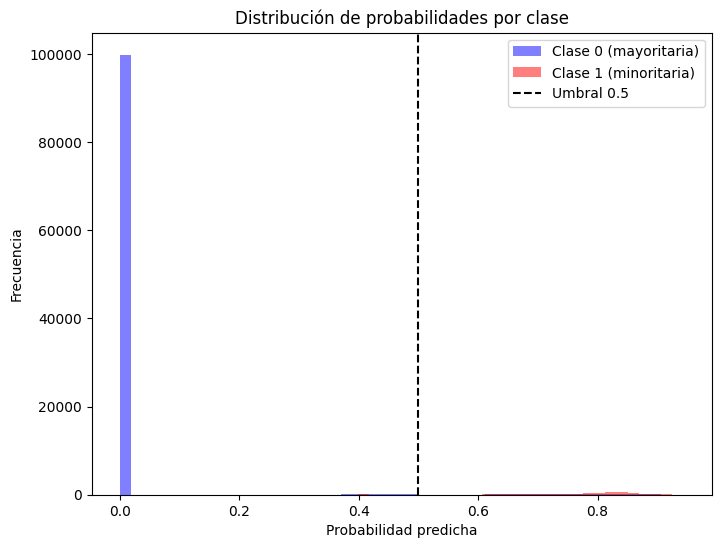

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_1_test)[np.array(all_labels_m2_1_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_1_test)[np.array(all_labels_m2_1_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

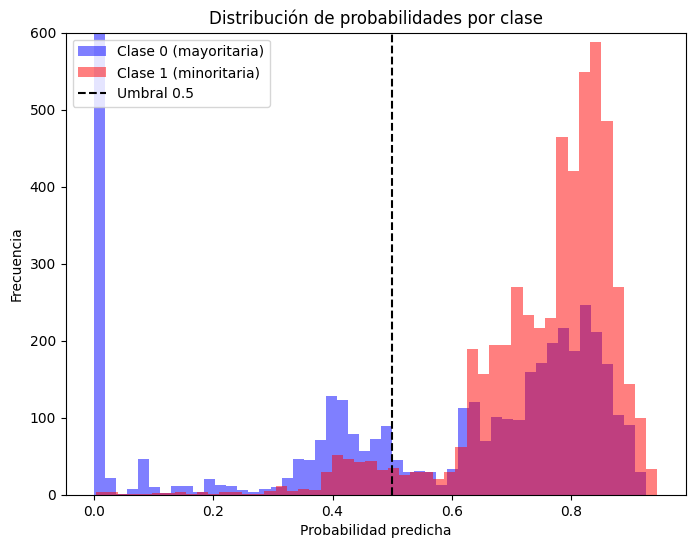

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_1_test)[np.array(all_labels_m2_1_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_1_test)[np.array(all_labels_m2_1_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,600))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-113-e6deb1e134a1>:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


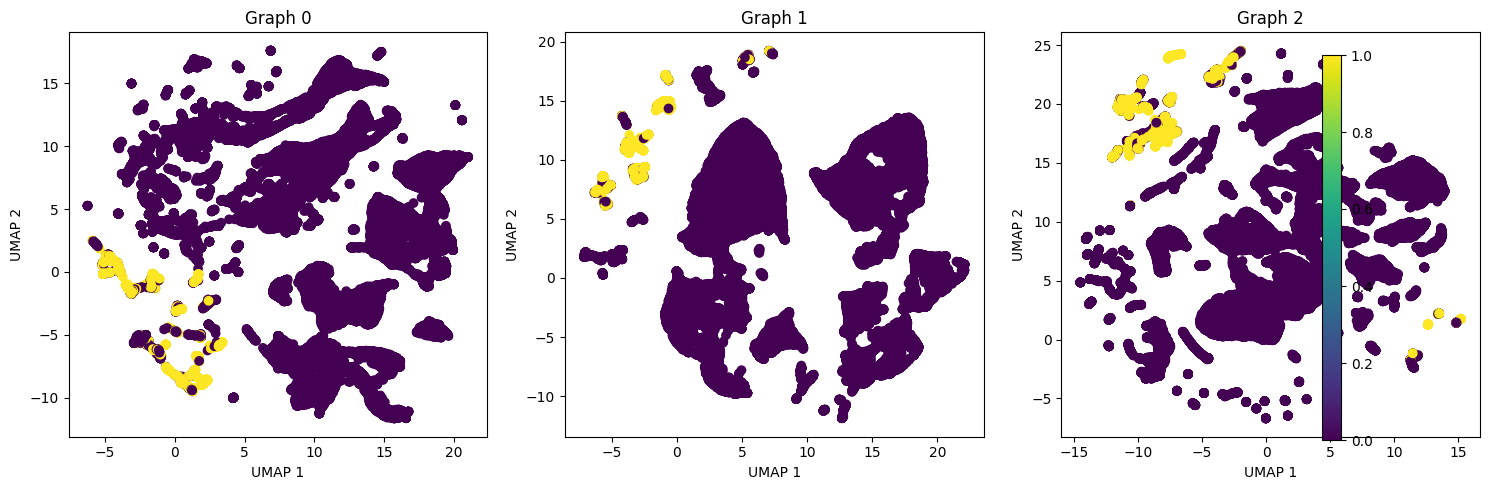

In [ ]:
num_graphs = len(last_windows_for_test)
rows, cols = 1,3

fig, axes = plt.subplots(rows, cols, figsize=(15,5))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_test_m2_1[i]  # Feature embeddings
    y = last_windows_for_test[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

#### Model 2_2: Reusing h

In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_2 = EdgeClassificationModel_RNN_v2(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32)#, seq_len=4)
model2_2.to(device)
optimizer = torch.optim.Adam(model2_2.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
hidden_size_gru = 32
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

max_num_edges_train = max(list(set([graph.edge_index.shape[1] for i in range(25) for graph in windows_input_train[i]])))
max_num_edges_val = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_val[i]])))

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_2.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train[window][-1].y

        optimizer.zero_grad()
        out, _, _ = model2_2(data, max_num_edges_train)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    h_0 = torch.zeros(1, max_num_edges_val, hidden_size_gru).to(device)
    model2_2.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val)):
            data_list = windows_input_val[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val[window][-1].y
            out, h_n, _ = model2_2(data, max_num_edges_val, h_0)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
            h_0 = h_n
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2747, Val Loss: 0.1254, Current LR: 0.010000, ROC-AUC: 0.8887061503694363, F1:0.6792656587473002
Epoch 2/15, Train Loss: 0.0831, Val Loss: 0.0765, Current LR: 0.010000, ROC-AUC: 0.9178194421602129, F1:0.6666666666666666
Epoch 3/15, Train Loss: 0.0623, Val Loss: 0.0756, Current LR: 0.010000, ROC-AUC: 0.9447682977094742, F1:0.6820319849482597
Epoch 4/15, Train Loss: 0.0574, Val Loss: 0.0717, Current LR: 0.010000, ROC-AUC: 0.9321918267151533, F1:0.6845180136319376
Epoch 5/15, Train Loss: 0.0563, Val Loss: 0.0803, Current LR: 0.010000, ROC-AUC: 0.9759810520459608, F1:0.6981556455240666
Epoch 6/15, Train Loss: 0.0572, Val Loss: 0.0765, Current LR: 0.010000, ROC-AUC: 0.9561650900393295, F1:0.6857142857142857
Epoch 7/15, Train Loss: 0.0541, Val Loss: 0.0738, Current LR: 0.010000, ROC-AUC: 0.945701279372679, F1:0.6858762399622107
Epoch 8/15, Train Loss: 0.0524, Val Loss: 0.0754, Current LR: 0.010000, ROC-AUC: 0.9493560497617292, F1:0.687646782527008
Epoch 9/15, Train 

In [ ]:
# Evaluación test
model2_2.eval()
all_probabilities_m2_2_test, all_preds_m2_2_test, all_labels_m2_2_test = [], [], []
embeddings_test_m2_2 = []

#max_num_edges_test = max(list(set([graph.edge_index.shape[1] for graph in windows_input_test[0]])))
max_num_edges_test = max(list(set([graph.edge_index.shape[1] for i in range(3) for graph in windows_input_test[i]])))
h_0 = torch.zeros(1, max_num_edges_test, hidden_size_gru).to(device)

with torch.no_grad():
    for window in range(len(windows_input_test)):
        data_list = windows_input_test[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test[window][-1].y
        out, h_n, emb_t = model2_2(data, max_num_edges_test, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        valid_emb = emb_t[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m2_2_test.extend(probabilities)
        all_preds_m2_2_test.extend(preds)
        all_labels_m2_2_test.extend(labels.cpu().numpy())
        embeddings_test_m2_2.append(valid_emb)
        h_0 = h_n

# Metrics
roc_auc_m2_2_test = roc_auc_score(all_labels_m2_2_test, all_preds_m2_2_test)
accuracy_m2_2_test = accuracy_score(all_labels_m2_2_test, all_preds_m2_2_test)
precision_m2_2_test = precision_score(all_labels_m2_2_test, all_preds_m2_2_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_2_test = recall_score(all_labels_m2_2_test, all_preds_m2_2_test, average='binary', zero_division=0)
f1_m2_2_test = f1_score(all_labels_m2_2_test, all_preds_m2_2_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_2_test:.4f}")
print(f"Accuracy: {accuracy_m2_2_test:.4f}")
print(f"Precision: {precision_m2_2_test:.4f}")
print(f"Recall: {recall_m2_2_test:.4f}")
print(f"F1: {f1_m2_2_test:.4f}")

# ROC-AUC: 0.9012
# Accuracy: 0.9686
# Precision: 0.6369
# Recall: 0.8265
# F1: 0.7194

ROC-AUC: 0.9641
Accuracy: 0.9691
Precision: 0.6180
Recall: 0.9586
F1: 0.7515


In [ ]:
precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN = precision_recall_full(all_labels_m2_2_test, all_preds_m2_2_test)

print(f"Precisión (clase 1): {precision_1:.4f}")
print(f"Recall (clase 1): {recall_1:.4f}")
print(f"Precisión (clase 0): {precision_0:.4f}")
print(f"Recall (clase 0): {recall_0:.4f}")

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")

Precisión (clase 1): 0.6180
Recall (clase 1): 0.9586
Precisión (clase 0): 0.9978
Recall (clase 0): 0.9697
TP: 5065
FP: 3131
TN: 100165
FN: 219


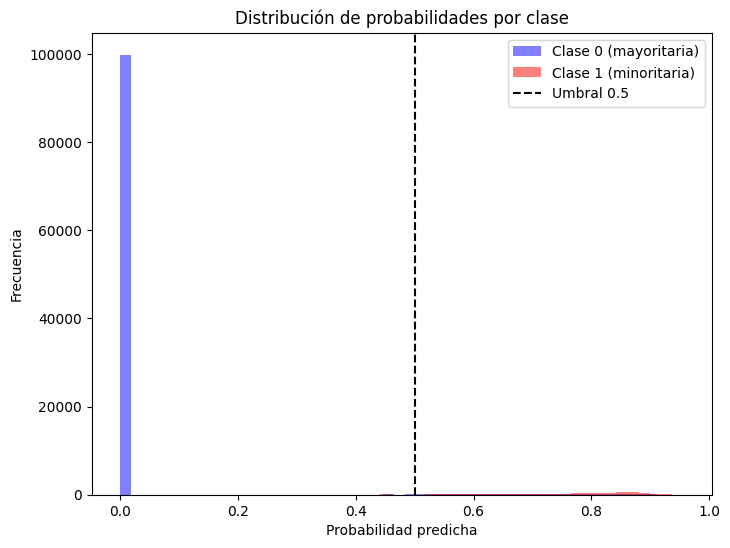

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_2_test)[np.array(all_labels_m2_2_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_2_test)[np.array(all_labels_m2_2_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

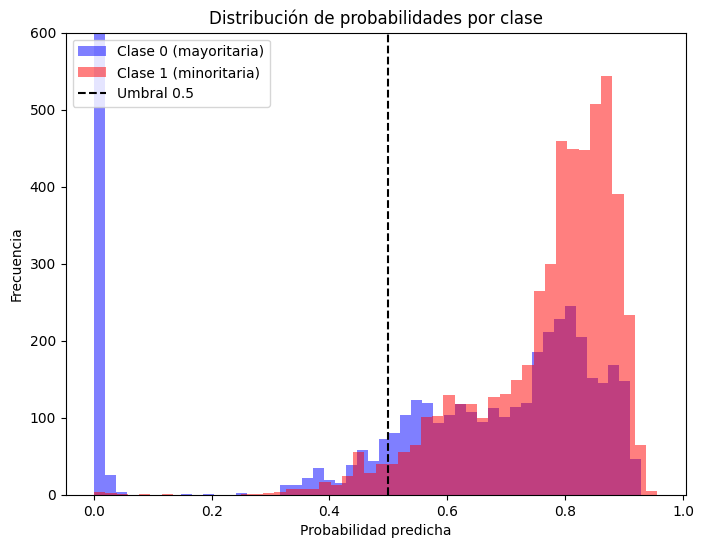

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_2_test)[np.array(all_labels_m2_2_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_2_test)[np.array(all_labels_m2_2_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,600))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-128-b09b536c4436>:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


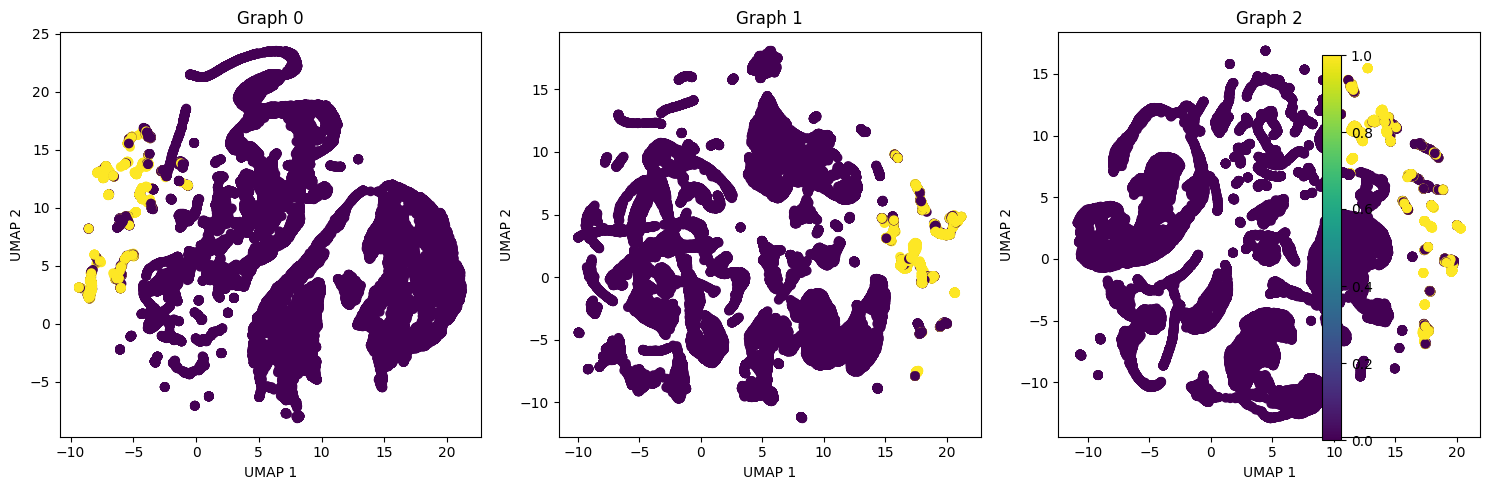

In [ ]:
num_graphs = len(last_windows_for_test)
rows, cols = 1,3

fig, axes = plt.subplots(rows, cols, figsize=(15,5))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_test_m2_2[i]  # Feature embeddings
    y = last_windows_for_test[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

#### Model 2_2_1: Reusing h for training

In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_2_1 = EdgeClassificationModel_RNN_v3(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32)#, seq_len=4)
model2_2_1.to(device)
optimizer = torch.optim.Adam(model2_2_1.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
hidden_size_gru = 32
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

max_num_edges_train = max(list(set([graph.edge_index.shape[1] for i in range(25) for graph in windows_input_train[i]])))
max_num_edges_val = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_val[i]])))

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_2_1.train()
    epoch_loss = 0
    total_edges = 0
    h_0 = torch.zeros(1, max_num_edges_train, hidden_size_gru).to(device).detach()
    for window in range(len(windows_input_train)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train[window][-1].y

        optimizer.zero_grad()
        out, h_n, _ = model2_2_1(data, max_num_edges_train, h_0)
        h_n = h_n.detach()
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        h_0 = h_n

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    h_0 = torch.zeros(1, max_num_edges_val, hidden_size_gru).to(device)
    model2_2_1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val)):
            data_list = windows_input_val[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val[window][-1].y
            out, h_n, _ = model2_2_1(data, max_num_edges_val, h_0)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
            h_0 = h_n
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2889, Val Loss: 0.1836, Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 2/15, Train Loss: 0.1981, Val Loss: 0.1217, Current LR: 0.010000, ROC-AUC: 0.5795176515257651, F1:0.2678002125398512
Epoch 3/15, Train Loss: 0.0850, Val Loss: 0.0828, Current LR: 0.010000, ROC-AUC: 0.9020815947793634, F1:0.6463354648303
Epoch 4/15, Train Loss: 0.0645, Val Loss: 0.0840, Current LR: 0.010000, ROC-AUC: 0.9451622007402941, F1:0.6737720111214087
Epoch 5/15, Train Loss: 0.0605, Val Loss: 0.0743, Current LR: 0.010000, ROC-AUC: 0.9591315453384419, F1:0.6925925925925925
Epoch 6/15, Train Loss: 0.0575, Val Loss: 0.0714, Current LR: 0.010000, ROC-AUC: 0.937035412694642, F1:0.686624818928054
Epoch 7/15, Train Loss: 0.0544, Val Loss: 0.0691, Current LR: 0.010000, ROC-AUC: 0.9454251411655062, F1:0.695819317635752
Epoch 8/15, Train Loss: 0.0514, Val Loss: 0.0683, Current LR: 0.010000, ROC-AUC: 0.9037008611045122, F1:0.6643073811931244
Epoch 9/15, Train Loss: 0.0489, Val Loss: 0.0695, Cu

In [ ]:
# Evaluación test
model2_2_1.eval()
all_probabilities_m2_2_1_test, all_preds_m2_2_1_test, all_labels_m2_2_1_test = [], [], []
embeddings_test_m2_2_1 = []

#max_num_edges_test = max(list(set([graph.edge_index.shape[1] for graph in windows_input_test[0]])))
max_num_edges_test = max(list(set([graph.edge_index.shape[1] for i in range(3) for graph in windows_input_test[i]])))
h_0 = torch.zeros(1, max_num_edges_test, hidden_size_gru).to(device)

with torch.no_grad():
    for window in range(len(windows_input_test)):
        data_list = windows_input_test[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test[window][-1].y
        out, h_n, emb_t = model2_2_1(data, max_num_edges_test, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        valid_emb = emb_t[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m2_2_1_test.extend(probabilities)
        all_preds_m2_2_1_test.extend(preds)
        all_labels_m2_2_1_test.extend(labels.cpu().numpy())
        embeddings_test_m2_2_1.append(valid_emb)
        h_0 = h_n

# Metrics
roc_auc_m2_2_1_test = roc_auc_score(all_labels_m2_2_1_test, all_preds_m2_2_1_test)
accuracy_m2_2_1_test = accuracy_score(all_labels_m2_2_1_test, all_preds_m2_2_1_test)
precision_m2_2_1_test = precision_score(all_labels_m2_2_1_test, all_preds_m2_2_1_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_2_1_test = recall_score(all_labels_m2_2_1_test, all_preds_m2_2_1_test, average='binary', zero_division=0)
f1_m2_2_1_test = f1_score(all_labels_m2_2_1_test, all_preds_m2_2_1_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_2_1_test:.4f}")
print(f"Accuracy: {accuracy_m2_2_1_test:.4f}")
print(f"Precision: {precision_m2_2_1_test:.4f}")
print(f"Recall: {recall_m2_2_1_test:.4f}")
print(f"F1: {f1_m2_2_1_test:.4f}")

# ROC-AUC: 0.9559
# Accuracy: 0.9766
# Precision: 0.6897
# Recall: 0.9330
# F1: 0.7931

ROC-AUC: 0.9571
Accuracy: 0.9736
Precision: 0.6608
Recall: 0.9389
F1: 0.7756


In [ ]:
precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN = precision_recall_full(all_labels_m2_2_1_test, all_preds_m2_2_1_test)

print(f"Precisión (clase 1): {precision_1:.4f}")
print(f"Recall (clase 1): {recall_1:.4f}")
print(f"Precisión (clase 0): {precision_0:.4f}")
print(f"Recall (clase 0): {recall_0:.4f}")

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")

Precisión (clase 1): 0.6608
Recall (clase 1): 0.9389
Precisión (clase 0): 0.9968
Recall (clase 0): 0.9753
TP: 4961
FP: 2547
TN: 100749
FN: 323


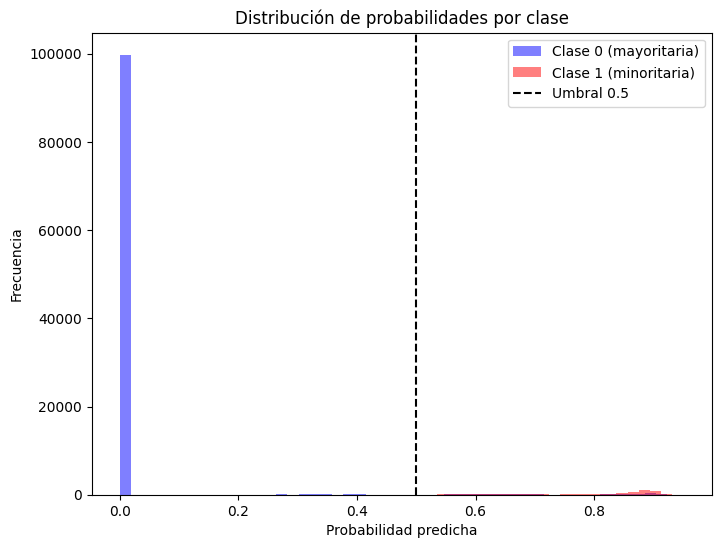

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_2_1_test)[np.array(all_labels_m2_2_1_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_2_1_test)[np.array(all_labels_m2_2_1_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

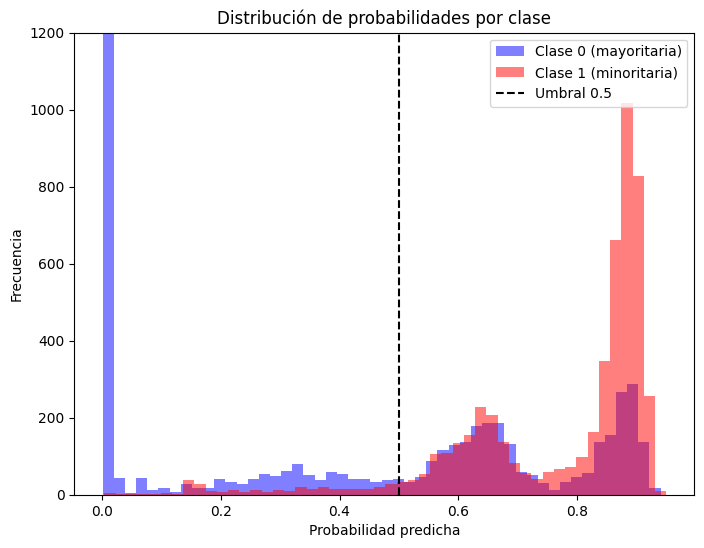

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_2_1_test)[np.array(all_labels_m2_2_1_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_2_1_test)[np.array(all_labels_m2_2_1_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,1200))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-138-5f0fad26dbc8>:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


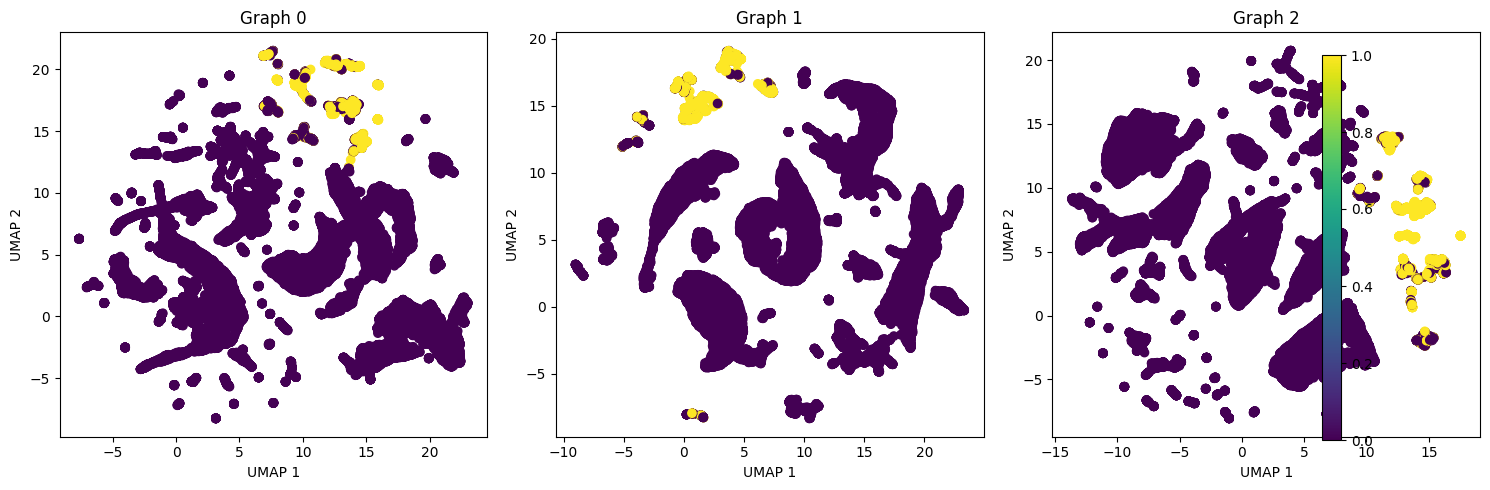

In [ ]:
num_graphs = len(last_windows_for_test)
rows, cols = 1,3

fig, axes = plt.subplots(rows, cols, figsize=(15,5))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_test_m2_2_1[i]  # Feature embeddings
    y = last_windows_for_test[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

#### Comparacion sobre test: seq_len=4

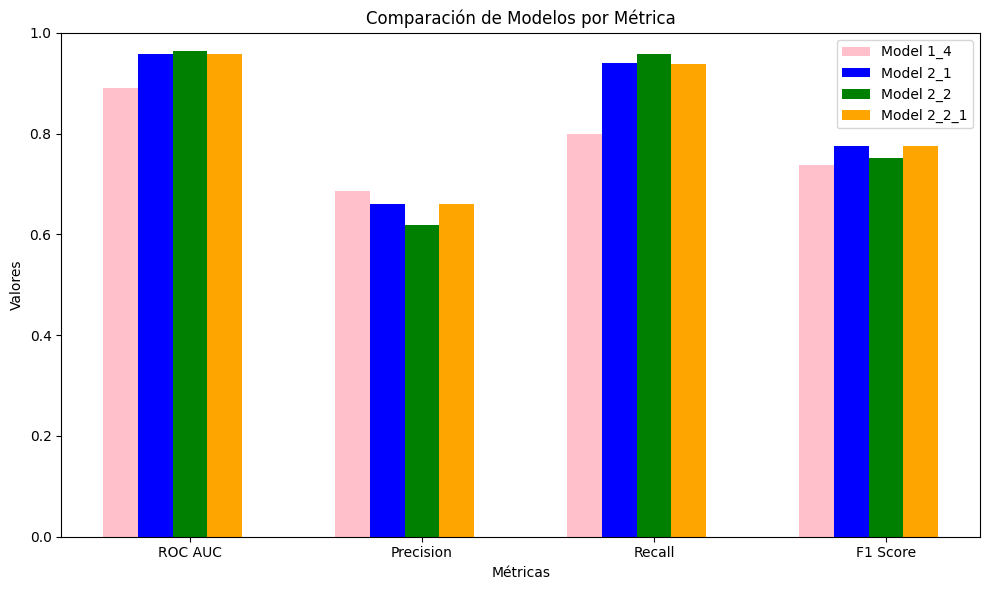

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las métricas
#metric_names = ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_names = ['ROC AUC', 'Precision', 'Recall', 'F1 Score']

# Nombres de los modelos
model_names = ['Model 1_4', 'Model 2_1', 'Model 2_2', 'Model 2_2_1']

# Valores de las métricas para cada modelo
roc_auc = [roc_auc_m1_4_test, roc_auc_m2_1_test, roc_auc_m2_2_test, roc_auc_m2_2_1_test]
accuracy = [accuracy_m1_4_test, accuracy_m2_1_test, accuracy_m2_2_test, accuracy_m2_2_1_test]
precision = [precision_m1_4_test, precision_m2_1_test, precision_m2_2_test, precision_m2_2_1_test]
recall = [recall_m1_4_test, recall_m2_1_test, recall_m2_2_test, recall_m2_2_1_test]
f1 = [f1_m1_4_test, f1_m2_1_test, f1_m2_2_test, f1_m2_2_1_test]


# Lista de métricas agrupadas
#metrics = [roc_auc, accuracy, precision, recall, f1]
metrics = [roc_auc, precision, recall, f1]

# Colores para los modelos
colors = ['pink', 'blue', 'green', 'orange']

# Crear el gráfico de barras agrupadas por métrica
x = np.arange(len(metric_names))  # Posiciones para las métricas
bar_width = 0.15  # Ancho de las barras

plt.figure(figsize=(10, 6))
for i, (model, color) in enumerate(zip(model_names, colors)):
    model_values = [metric[i] for metric in metrics]
    plt.bar(x + i * bar_width, model_values, width=bar_width, label=model, color=color)

# Personalización del gráfico
plt.xticks(x + 2 * bar_width, metric_names)
plt.xlabel('Métricas')
plt.ylabel('Valores')
plt.ylim((0,1))
plt.title('Comparación de Modelos por Métrica')
plt.legend(loc='upper right')
plt.tight_layout()

# Mostrar el gráfico
plt.show()



### Model 2_3: seq_len= 6 - 25 windows for train, 1 for val

In [22]:
windows_input_train2, windows_input_val2 = generate_sliding_windows(torch_geo_graphs_unsw1_proto_more_rnn, 30, 6, True)

In [23]:
print(len(windows_input_train),len(windows_input_train2))
print(len(windows_input_val),len(windows_input_val2))

25 25
5 1


In [24]:
windows_input_test2 = generate_sliding_windows(torch_geo_graphs_unsw2_proto_more_rnn, 6, 6, False)

In [25]:
windows_input_test2

[[Data(x=[262986, 14], edge_index=[2, 13377], edge_attr=[13377, 3], y=[13377]),
  Data(x=[262986, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
  Data(x=[262986, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
  Data(x=[262986, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695]),
  Data(x=[262986, 14], edge_index=[2, 35200], edge_attr=[35200, 3], y=[35200]),
  Data(x=[262986, 14], edge_index=[2, 38685], edge_attr=[38685, 3], y=[38685])]]

In [26]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_3 = EdgeClassificationModel_RNN(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32, seq_len=4)
optimizer = torch.optim.Adam(model2_3.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_3.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train2)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train2[window][-1].y

        optimizer.zero_grad()
        out, _ = model2_3(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    model2_3.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val2)):
            data_list = windows_input_val2[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val2[window][-1].y
            out, _ = model2_3(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2723, Val Loss: 0.2403, Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 2/15, Train Loss: 0.1361, Val Loss: 0.0855, Current LR: 0.010000, ROC-AUC: 0.8294356292823657, F1:0.7584541062801933
Epoch 3/15, Train Loss: 0.0667, Val Loss: 0.0485, Current LR: 0.010000, ROC-AUC: 0.9194644789037143, F1:0.8392484342379958
Epoch 4/15, Train Loss: 0.0596, Val Loss: 0.0382, Current LR: 0.010000, ROC-AUC: 0.987565040440987, F1:0.9155206286836935
Epoch 5/15, Train Loss: 0.0554, Val Loss: 0.0385, Current LR: 0.010000, ROC-AUC: 0.9768198444181134, F1:0.902970297029703
Epoch 6/15, Train Loss: 0.0540, Val Loss: 0.0373, Current LR: 0.010000, ROC-AUC: 0.9831757766215031, F1:0.9094488188976378
Epoch 7/15, Train Loss: 0.0535, Val Loss: 0.0376, Current LR: 0.010000, ROC-AUC: 0.9810571325537066, F1:0.9072978303747534
Epoch 8/15, Train Loss: 0.0519, Val Loss: 0.0373, Current LR: 0.010000, ROC-AUC: 0.97893848848591, F1:0.9051383399209486
Epoch 9/15, Train Loss: 0.0528, Val Loss: 0.0368, 

In [30]:
windows_input_test2

[[Data(x=[262986, 14], edge_index=[2, 13377], edge_attr=[13377, 3], y=[13377]),
  Data(x=[262986, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
  Data(x=[262986, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
  Data(x=[262986, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695]),
  Data(x=[262986, 14], edge_index=[2, 35200], edge_attr=[35200, 3], y=[35200]),
  Data(x=[262986, 14], edge_index=[2, 38685], edge_attr=[38685, 3], y=[38685])]]

In [28]:
# Evaluación test
model2_3.eval()
all_probabilities_m2_3_test, all_preds_m2_3_test, all_labels_m2_3_test = [], [], []
embeddings_test_m2_3 = []
with torch.no_grad():
    for window in range(len(windows_input_test2)):
        data_list = windows_input_test2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test2[window][-1].y
        out, emb_t = model2_3(data)
        mask = len(labels)
        valid_out = out[:mask]
        valid_emb = emb_t[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m2_3_test.extend(probabilities)
        all_preds_m2_3_test.extend(preds)
        all_labels_m2_3_test.extend(labels.cpu().numpy())
        embeddings_test_m2_3.append(valid_emb)

# Metrics
roc_auc_m2_3_test = roc_auc_score(all_labels_m2_3_test, all_preds_m2_3_test)
accuracy_m2_3_test = accuracy_score(all_labels_m2_3_test, all_preds_m2_3_test)
precision_m2_3_test = precision_score(all_labels_m2_3_test, all_preds_m2_3_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_3_test = recall_score(all_labels_m2_3_test, all_preds_m2_3_test, average='binary', zero_division=0)
f1_m2_3_test = f1_score(all_labels_m2_3_test, all_preds_m2_3_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_3_test:.4f}")
print(f"Accuracy: {accuracy_m2_3_test:.4f}")
print(f"Precision: {precision_m2_3_test:.4f}")
print(f"Recall: {recall_m2_3_test:.4f}")
print(f"F1: {f1_m2_3_test:.4f}")

# ROC-AUC: 0.8680
# Accuracy: 0.9628
# Precision: 0.5990
# Recall: 0.7628
# F1: 0.6711

ROC-AUC: 0.9545
Accuracy: 0.9650
Precision: 0.5934
Recall: 0.9429
F1: 0.7284


In [29]:
precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN = precision_recall_full(all_labels_m2_3_test, all_preds_m2_3_test)

print(f"Precisión (clase 1): {precision_1:.4f}")
print(f"Recall (clase 1): {recall_1:.4f}")
print(f"Precisión (clase 0): {precision_0:.4f}")
print(f"Recall (clase 0): {recall_0:.4f}")

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")

Precisión (clase 1): 0.5934
Recall (clase 1): 0.9429
Precisión (clase 0): 0.9969
Recall (clase 0): 0.9661
TP: 1817
FP: 1245
TN: 35513
FN: 110


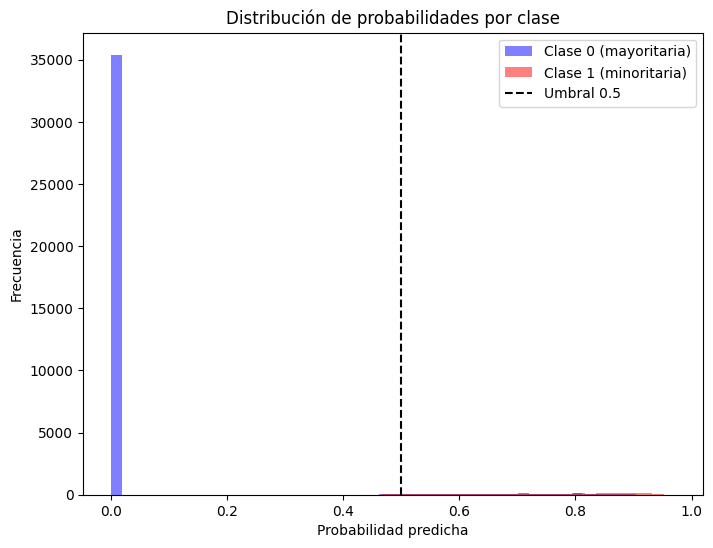

In [31]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_3_test)[np.array(all_labels_m2_3_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_3_test)[np.array(all_labels_m2_3_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

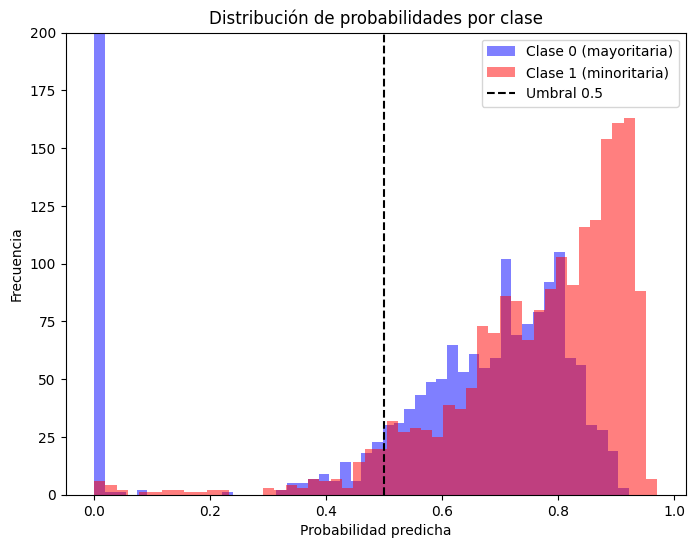

In [33]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_3_test)[np.array(all_labels_m2_3_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_3_test)[np.array(all_labels_m2_3_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,200))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-36-e7bae2f48992>:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


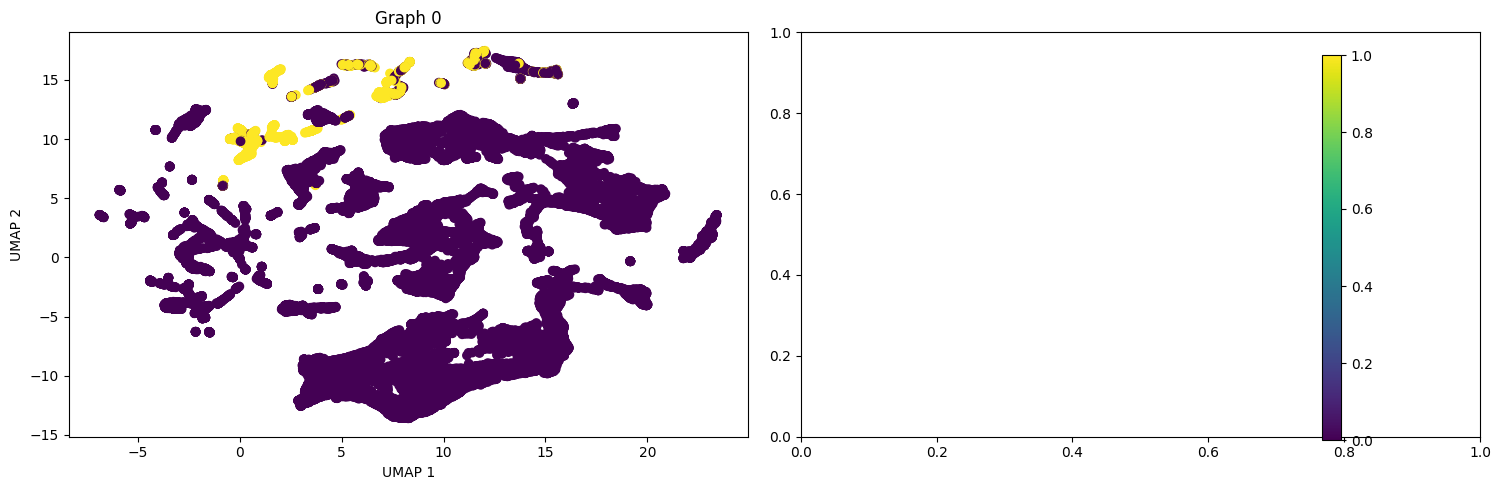

In [36]:
last_windows_for_test2 = [windows_input_test2[i][-1] for i in range(len(windows_input_test2))]

num_graphs = len(last_windows_for_test2)
rows, cols = 1,2

fig, axes = plt.subplots(rows, cols, figsize=(15,5))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_test_m2_3[i]  # Feature embeddings
    y = last_windows_for_test2[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

#### Model 1_4_1: traditional using same train set as model 2_3

In [37]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1_4_1 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1_4_1.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows2 = list(range(30))
val_windows2 = list(range(35,36)) # una sola captura para validar (la ultima)


# Train
epochs = 15
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1_4_1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows2:
        data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
        optimizer.zero_grad()
        out,_ = model1_4_1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1_4_1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows2:
            data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
            out,_ = model1_4_1(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/15, Train Loss: 0.1897, Val Loss: 0.0568, , Current LR: 0.010000, ROC-AUC: 0.9701599608469424, F1:0.8928571428571429
Epoch 2/15, Train Loss: 0.0835, Val Loss: 0.0520, , Current LR: 0.010000, ROC-AUC: 0.9747012003503167, F1:0.9007936507936508
Epoch 3/15, Train Loss: 0.0711, Val Loss: 0.0481, , Current LR: 0.010000, ROC-AUC: 0.97893848848591, F1:0.9051383399209486
Epoch 4/15, Train Loss: 0.0639, Val Loss: 0.0471, , Current LR: 0.010000, ROC-AUC: 0.9217350986554016, F1:0.8434237995824635
Epoch 5/15, Train Loss: 0.0579, Val Loss: 0.0483, , Current LR: 0.010000, ROC-AUC: 0.9069045901808253, F1:0.826271186440678
Epoch 6/15, Train Loss: 0.0559, Val Loss: 0.0491, , Current LR: 0.010000, ROC-AUC: 0.8984300139096388, F1:0.8162393162393162
Epoch 7/15, Train Loss: 0.0548, Val Loss: 0.0487, , Current LR: 0.010000, ROC-AUC: 0.9026673020452322, F1:0.8212765957446808
Epoch 8/15, Train Loss: 0.0541, Val Loss: 0.0479, , Current LR: 0.010000, ROC-AUC: 0.9047859461130288, F1:0.8237791932059448
Epo

In [38]:
# Evaluación test
model1_4_1.eval()
all_probabilities_m1_4_1_test, all_preds_m1_4_1_test, all_labels_m1_4_1_test = [], [], []

last_windows_for_test2 = [windows_input_test2[i][-1] for i in range(len(windows_input_test2))]

embeddings_test_m1_4_1 = []
with torch.no_grad():
    for window in range(len(last_windows_for_test2)):
        data = last_windows_for_test2[window].to(device)
        labels = last_windows_for_test2[window].y
        out, emb_t = model1_4_1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m1_4_1_test.extend(probabilities)
        all_preds_m1_4_1_test.extend(preds)
        all_labels_m1_4_1_test.extend(labels.cpu().numpy())
        embeddings_test_m1_4_1.append(emb_t)

# Metrics
roc_auc_m1_4_1_test = roc_auc_score(all_labels_m1_4_1_test, all_preds_m1_4_1_test)
accuracy_m1_4_1_test = accuracy_score(all_labels_m1_4_1_test, all_preds_m1_4_1_test)
precision_m1_4_1_test = precision_score(all_labels_m1_4_1_test, all_preds_m1_4_1_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_4_1_test = recall_score(all_labels_m1_4_1_test, all_preds_m1_4_1_test, average='binary', zero_division=0)
f1_m1_4_1_test = f1_score(all_labels_m1_4_1_test, all_preds_m1_4_1_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_4_1_test:.4f}")
print(f"Accuracy: {accuracy_m1_4_1_test:.4f}")
print(f"Precision: {precision_m1_4_1_test:.4f}")
print(f"Recall: {recall_m1_4_1_test:.4f}")
print(f"F1: {f1_m1_4_1_test:.4f}")

ROC-AUC: 0.8810
Accuracy: 0.9686
Precision: 0.6548
Recall: 0.7836
F1: 0.7134


In [39]:
precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN = precision_recall_full(all_labels_m1_4_1_test, all_preds_m1_4_1_test)

print(f"Precisión (clase 1): {precision_1:.4f}")
print(f"Recall (clase 1): {recall_1:.4f}")
print(f"Precisión (clase 0): {precision_0:.4f}")
print(f"Recall (clase 0): {recall_0:.4f}")

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")

Precisión (clase 1): 0.6548
Recall (clase 1): 0.7836
Precisión (clase 0): 0.9885
Recall (clase 0): 0.9783
TP: 1510
FP: 796
TN: 35962
FN: 417


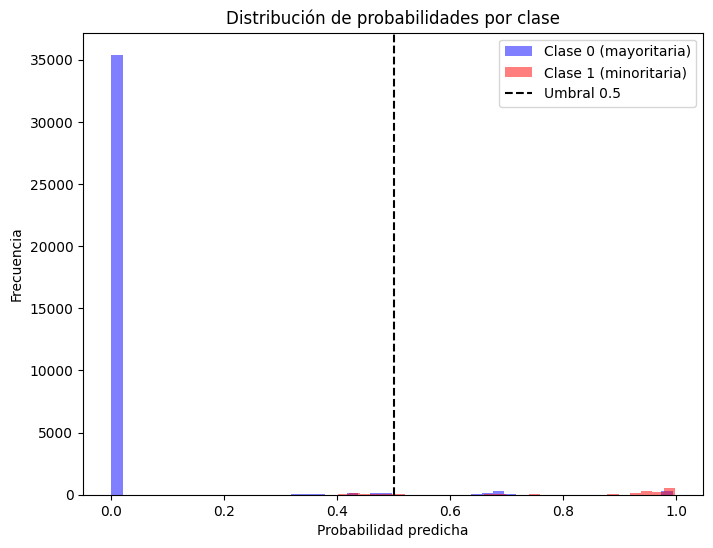

In [40]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m1_4_1_test)[np.array(all_labels_m1_4_1_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m1_4_1_test)[np.array(all_labels_m1_4_1_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

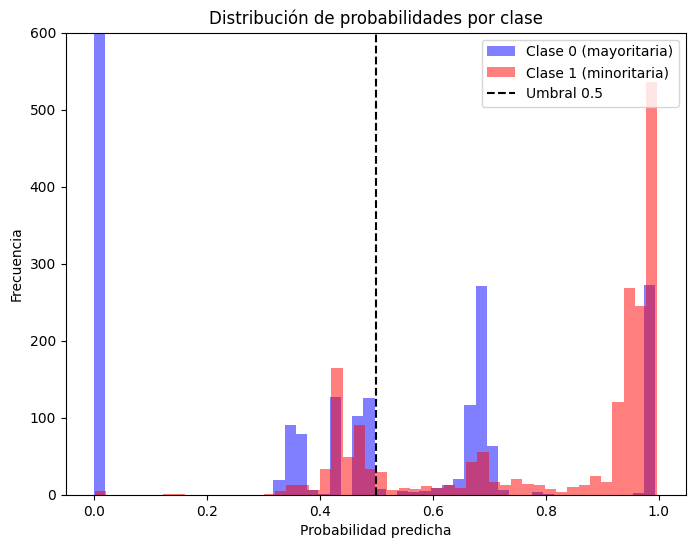

In [43]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m1_4_1_test)[np.array(all_labels_m1_4_1_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m1_4_1_test)[np.array(all_labels_m1_4_1_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,600))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-44-334d6fdd4c7b>:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


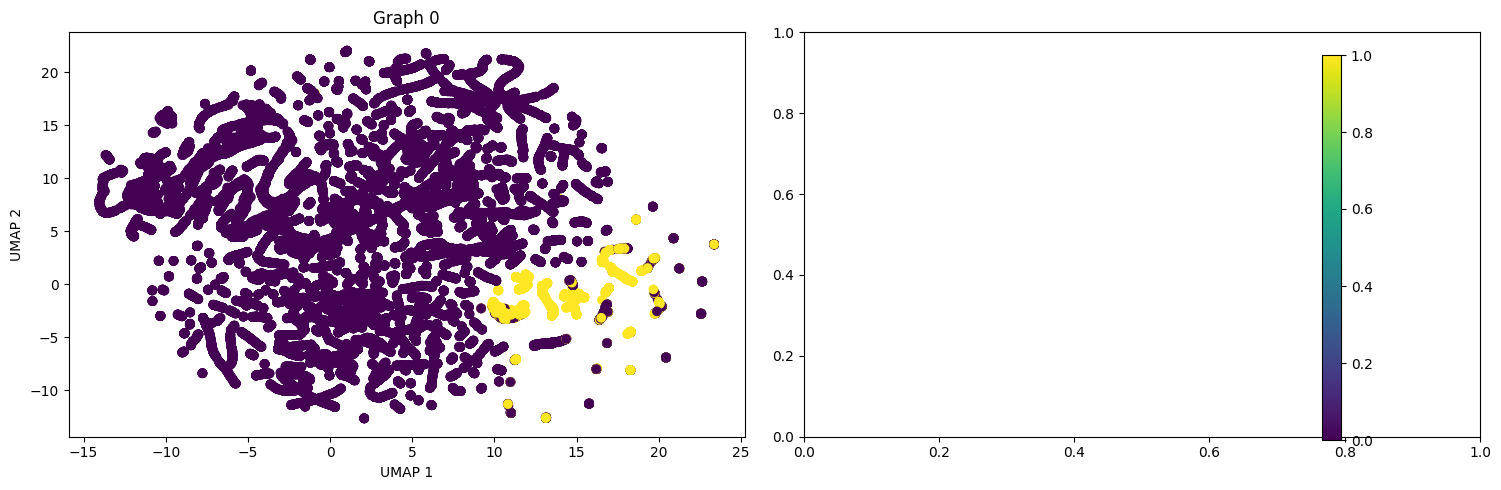

In [44]:
last_windows_for_test2 = [windows_input_test2[i][-1] for i in range(len(windows_input_test2))]

num_graphs = len(last_windows_for_test2)
rows, cols = 1,2

fig, axes = plt.subplots(rows, cols, figsize=(15,5))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_test_m1_4_1[i]  # Feature embeddings
    y = last_windows_for_test2[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

#### Comparacion sobre test: seq_len=6 - 25 windows for train, 1 for val

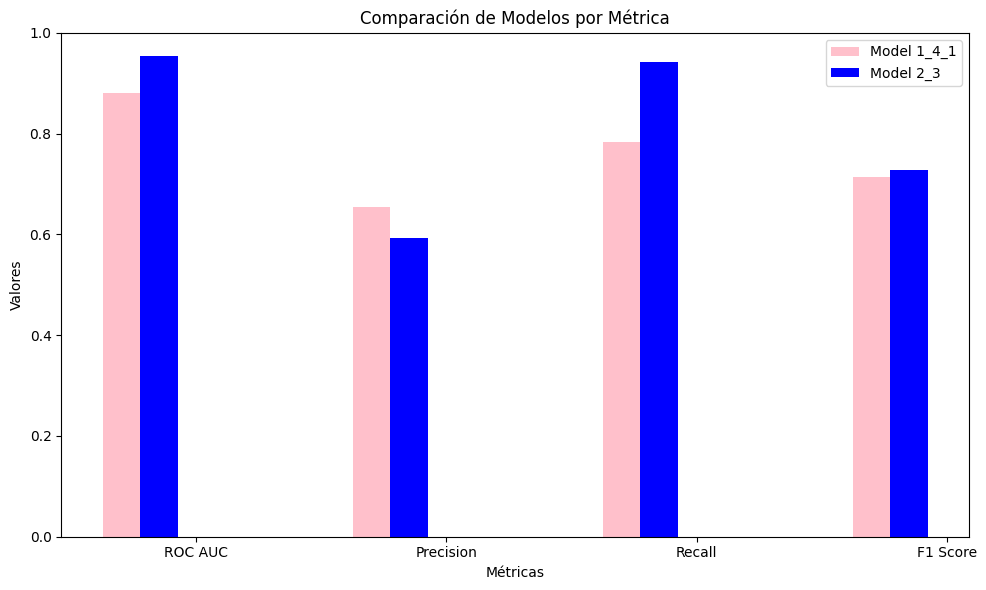

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las métricas
#metric_names = ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_names = ['ROC AUC', 'Precision', 'Recall', 'F1 Score']

# Nombres de los modelos
model_names = ['Model 1_4_1', 'Model 2_3']

# Valores de las métricas para cada modelo
roc_auc = [roc_auc_m1_4_1_test, roc_auc_m2_3_test]
accuracy = [accuracy_m1_4_1_test, accuracy_m2_3_test]
precision = [precision_m1_4_1_test, precision_m2_3_test]
recall = [recall_m1_4_1_test, recall_m2_3_test]
f1 = [f1_m1_4_1_test, f1_m2_3_test]


# Lista de métricas agrupadas
#metrics = [roc_auc, accuracy, precision, recall, f1]
metrics = [roc_auc, precision, recall, f1]

# Colores para los modelos
colors = ['pink', 'blue']#, 'green', 'orange']

# Crear el gráfico de barras agrupadas por métrica
x = np.arange(len(metric_names))  # Posiciones para las métricas
bar_width = 0.15  # Ancho de las barras

plt.figure(figsize=(10, 6))
for i, (model, color) in enumerate(zip(model_names, colors)):
    model_values = [metric[i] for metric in metrics]
    plt.bar(x + i * bar_width, model_values, width=bar_width, label=model, color=color)

# Personalización del gráfico
plt.xticks(x + 2 * bar_width, metric_names)
plt.xlabel('Métricas')
plt.ylabel('Valores')
plt.ylim((0,1))
plt.title('Comparación de Modelos por Métrica')
plt.legend(loc='upper right')
plt.tight_layout()

# Mostrar el gráfico
plt.show()



### Model 2_4: seq_len=6 - 21 windows for train, 5 for val

In [47]:
windows_input_train3, windows_input_val3 = generate_sliding_windows(torch_geo_graphs_unsw1_proto_more_rnn, 26, 6, True)

In [48]:
print(len(windows_input_train),len(windows_input_train3))

25 21


In [49]:
print(len(windows_input_val),len(windows_input_val3))

5 5


In [52]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_4 = EdgeClassificationModel_RNN(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32, seq_len=4)
optimizer = torch.optim.Adam(model2_4.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_4.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train3)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train3[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train3[window][-1].y

        optimizer.zero_grad()
        out,_ = model2_4(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    model2_4.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val3)):
            data_list = windows_input_val3[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val3[window][-1].y
            out,_ = model2_4(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2691, Val Loss: 0.1138, Current LR: 0.010000, ROC-AUC: 0.8635349345288493, F1:0.669327251995439
Epoch 2/15, Train Loss: 0.0875, Val Loss: 0.0794, Current LR: 0.010000, ROC-AUC: 0.9535021837253076, F1:0.6884024219841639
Epoch 3/15, Train Loss: 0.0688, Val Loss: 0.0750, Current LR: 0.010000, ROC-AUC: 0.9473814585376452, F1:0.6851503759398496
Epoch 4/15, Train Loss: 0.0612, Val Loss: 0.0704, Current LR: 0.010000, ROC-AUC: 0.948923568599025, F1:0.6892975011786893
Epoch 5/15, Train Loss: 0.0587, Val Loss: 0.0699, Current LR: 0.010000, ROC-AUC: 0.961420852901583, F1:0.6921306948918545
Epoch 6/15, Train Loss: 0.0602, Val Loss: 0.0686, Current LR: 0.010000, ROC-AUC: 0.9458190441963261, F1:0.6871746332229058
Epoch 7/15, Train Loss: 0.0569, Val Loss: 0.0691, Current LR: 0.010000, ROC-AUC: 0.9511834349562545, F1:0.6885245901639344
Epoch 8/15, Train Loss: 0.0579, Val Loss: 0.0700, Current LR: 0.010000, ROC-AUC: 0.9555062161553034, F1:0.6911970190964136
Epoch 9/15, Train L

In [53]:
# Evaluación test
model2_4.eval()
all_probabilities_m2_4_test, all_preds_m2_4_test, all_labels_m2_4_test = [], [], []
embeddings_test_m2_4 = []
with torch.no_grad():
    for window in range(len(windows_input_test2)):
        data_list = windows_input_test2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test2[window][-1].y
        out, emb_t = model2_4(data)
        mask = len(labels)
        valid_out = out[:mask]
        valid_emb = emb_t[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m2_4_test.extend(probabilities)
        all_preds_m2_4_test.extend(preds)
        all_labels_m2_4_test.extend(labels.cpu().numpy())
        embeddings_test_m2_4.append(valid_emb)

# Metrics
roc_auc_m2_4_test = roc_auc_score(all_labels_m2_4_test, all_preds_m2_4_test)
accuracy_m2_4_test = accuracy_score(all_labels_m2_4_test, all_preds_m2_4_test)
precision_m2_4_test = precision_score(all_labels_m2_4_test, all_preds_m2_4_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_4_test = recall_score(all_labels_m2_4_test, all_preds_m2_4_test, average='binary', zero_division=0)
f1_m2_4_test = f1_score(all_labels_m2_4_test, all_preds_m2_4_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_4_test:.4f}")
print(f"Accuracy: {accuracy_m2_4_test:.4f}")
print(f"Precision: {precision_m2_4_test:.4f}")
print(f"Recall: {recall_m2_4_test:.4f}")
print(f"F1: {f1_m2_4_test:.4f}")

# ROC-AUC: 0.9032
# Accuracy: 0.9633
# Precision: 0.5935
# Recall: 0.8365
# F1: 0.6944

ROC-AUC: 0.9356
Accuracy: 0.9631
Precision: 0.5839
Recall: 0.9050
F1: 0.7098


In [54]:
precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN = precision_recall_full(all_labels_m2_4_test, all_preds_m2_4_test)

print(f"Precisión (clase 1): {precision_1:.4f}")
print(f"Recall (clase 1): {recall_1:.4f}")
print(f"Precisión (clase 0): {precision_0:.4f}")
print(f"Recall (clase 0): {recall_0:.4f}")

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")

Precisión (clase 1): 0.5839
Recall (clase 1): 0.9050
Precisión (clase 0): 0.9949
Recall (clase 0): 0.9662
TP: 1744
FP: 1243
TN: 35515
FN: 183


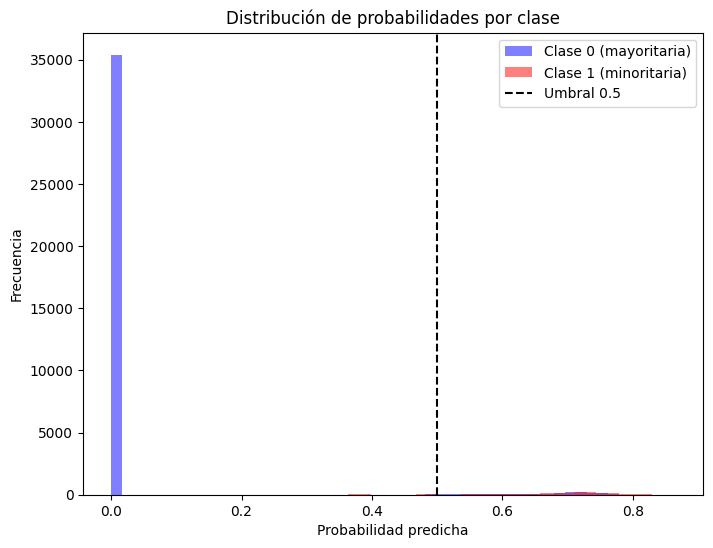

In [55]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_4_test)[np.array(all_labels_m2_4_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_4_test)[np.array(all_labels_m2_4_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

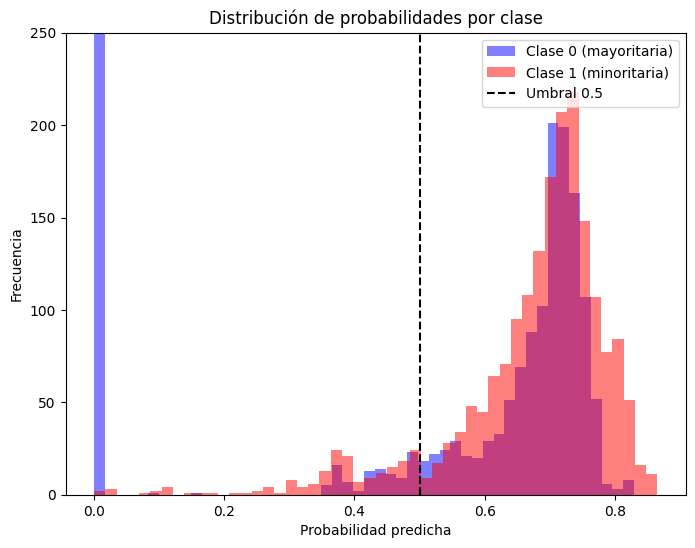

In [57]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_4_test)[np.array(all_labels_m2_4_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_4_test)[np.array(all_labels_m2_4_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,250))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-58-b610401719be>:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


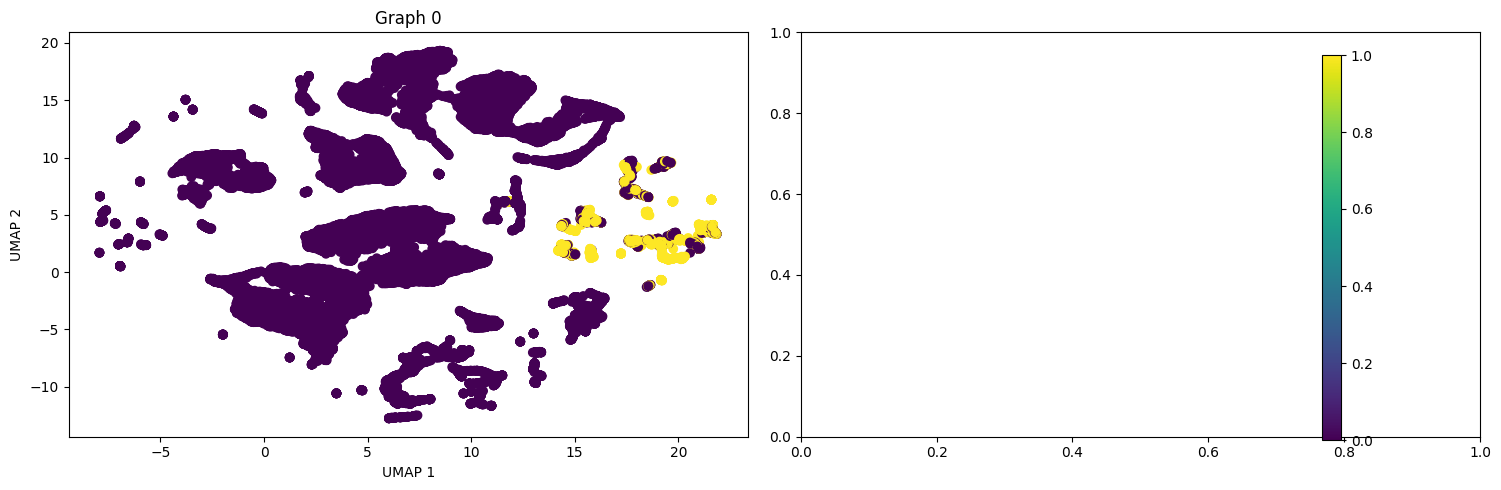

In [58]:
last_windows_for_test2 = [windows_input_test2[i][-1] for i in range(len(windows_input_test2))]

num_graphs = len(last_windows_for_test2)
rows, cols = 1,2

fig, axes = plt.subplots(rows, cols, figsize=(15,5))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_test_m2_4[i]  # Feature embeddings
    y = last_windows_for_test2[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

#### Model 1_4_2: traditional using same train set as model 2_4

In [60]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1_4_2 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1_4_2.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows3 = list(range(26))
val_windows3 = list(range(31,36))


# Train
epochs = 15
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1_4_2.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows3:
        data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
        optimizer.zero_grad()
        out,_ = model1_4_2(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1_4_2.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows3:
            data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
            out,_ = model1_4_2(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/15, Train Loss: 0.2429, Val Loss: 0.1072, , Current LR: 0.010000, ROC-AUC: 0.9423449818987344, F1:0.6508292245629762
Epoch 2/15, Train Loss: 0.0940, Val Loss: 0.0851, , Current LR: 0.010000, ROC-AUC: 0.9316070634529052, F1:0.6416289592760182
Epoch 3/15, Train Loss: 0.0800, Val Loss: 0.0754, , Current LR: 0.010000, ROC-AUC: 0.9322750742629038, F1:0.6425339366515838
Epoch 4/15, Train Loss: 0.0704, Val Loss: 0.0679, , Current LR: 0.010000, ROC-AUC: 0.9289837504847646, F1:0.7387580299785867
Epoch 5/15, Train Loss: 0.0622, Val Loss: 0.0632, , Current LR: 0.010000, ROC-AUC: 0.8485402237937735, F1:0.6867321867321867
Epoch 6/15, Train Loss: 0.0589, Val Loss: 0.0614, , Current LR: 0.010000, ROC-AUC: 0.8281354376689062, F1:0.6608150470219436
Epoch 7/15, Train Loss: 0.0580, Val Loss: 0.0612, , Current LR: 0.010000, ROC-AUC: 0.8370754121261221, F1:0.6724673710379118
Epoch 8/15, Train Loss: 0.0577, Val Loss: 0.0616, , Current LR: 0.010000, ROC-AUC: 0.8971415634701638, F1:0.7292501431024614


In [61]:
# Evaluación test
model1_4_2.eval()
all_probabilities_m1_4_2_test, all_preds_m1_4_2_test, all_labels_m1_4_2_test = [], [], []

last_windows_for_test2 = [windows_input_test2[i][-1] for i in range(len(windows_input_test2))]

embeddings_test_m1_4_2 = []
with torch.no_grad():
    for window in range(len(last_windows_for_test2)):
        data = last_windows_for_test2[window].to(device)
        labels = last_windows_for_test2[window].y
        out, emb_t = model1_4_2(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m1_4_2_test.extend(probabilities)
        all_preds_m1_4_2_test.extend(preds)
        all_labels_m1_4_2_test.extend(labels.cpu().numpy())
        embeddings_test_m1_4_2.append(emb_t)

# Metrics
roc_auc_m1_4_2_test = roc_auc_score(all_labels_m1_4_2_test, all_preds_m1_4_2_test)
accuracy_m1_4_2_test = accuracy_score(all_labels_m1_4_2_test, all_preds_m1_4_2_test)
precision_m1_4_2_test = precision_score(all_labels_m1_4_2_test, all_preds_m1_4_2_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_4_2_test = recall_score(all_labels_m1_4_2_test, all_preds_m1_4_2_test, average='binary', zero_division=0)
f1_m1_4_2_test = f1_score(all_labels_m1_4_2_test, all_preds_m1_4_2_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_4_2_test:.4f}")
print(f"Accuracy: {accuracy_m1_4_2_test:.4f}")
print(f"Precision: {precision_m1_4_2_test:.4f}")
print(f"Recall: {recall_m1_4_2_test:.4f}")
print(f"F1: {f1_m1_4_2_test:.4f}")

# ROC-AUC: 0.8749
# Accuracy: 0.9683
# Precision: 0.6538
# Recall: 0.7711
# F1: 0.7076

ROC-AUC: 0.8748
Accuracy: 0.9682
Precision: 0.6526
Recall: 0.7711
F1: 0.7069


In [62]:
precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN = precision_recall_full(all_labels_m1_4_2_test, all_preds_m1_4_2_test)

print(f"Precisión (clase 1): {precision_1:.4f}")
print(f"Recall (clase 1): {recall_1:.4f}")
print(f"Precisión (clase 0): {precision_0:.4f}")
print(f"Recall (clase 0): {recall_0:.4f}")

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")

Precisión (clase 1): 0.6526
Recall (clase 1): 0.7711
Precisión (clase 0): 0.9879
Recall (clase 0): 0.9785
TP: 1486
FP: 791
TN: 35967
FN: 441


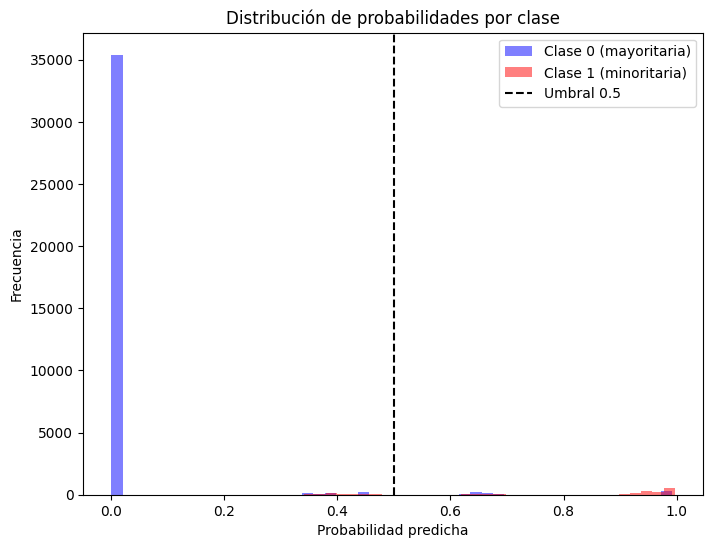

In [63]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m1_4_2_test)[np.array(all_labels_m1_4_2_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m1_4_2_test)[np.array(all_labels_m1_4_2_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

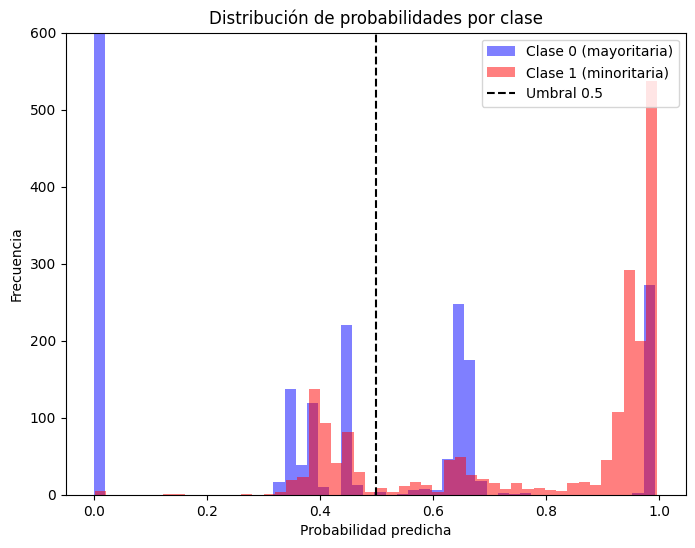

In [67]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m1_4_2_test)[np.array(all_labels_m1_4_2_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m1_4_2_test)[np.array(all_labels_m1_4_2_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,600))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-68-9ab92abcc6c0>:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


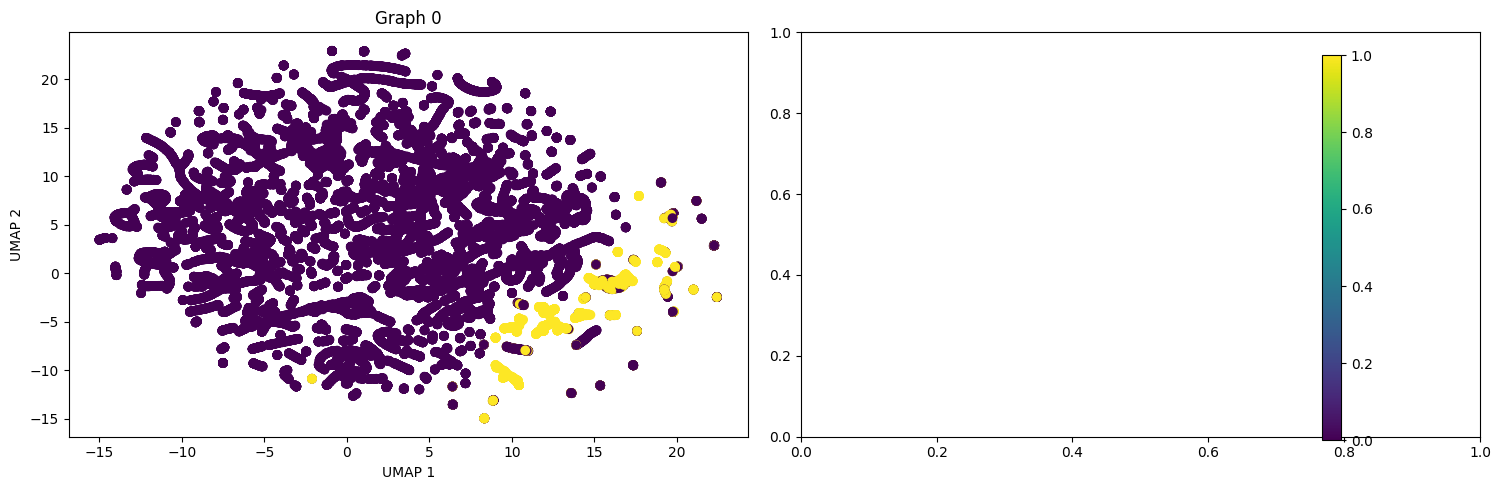

In [68]:
last_windows_for_test2 = [windows_input_test2[i][-1] for i in range(len(windows_input_test2))]

num_graphs = len(last_windows_for_test2)
rows, cols = 1,2

fig, axes = plt.subplots(rows, cols, figsize=(15,5))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_test_m1_4_2[i]  # Feature embeddings
    y = last_windows_for_test2[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

#### Model 2_5 Reusing h

In [69]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_5 = EdgeClassificationModel_RNN_v2(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32)#, seq_len=4)
model2_5.to(device)
optimizer = torch.optim.Adam(model2_5.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
hidden_size_gru = 32
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

max_num_edges_train3 = max(list(set([graph.edge_index.shape[1] for i in range(21) for graph in windows_input_train3[i]])))
max_num_edges_val3 = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_val3[i]])))

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_5.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train3)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train3[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train3[window][-1].y

        optimizer.zero_grad()
        out, _, _ = model2_5(data, max_num_edges_train3)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    h_0 = torch.zeros(1, max_num_edges_val3, hidden_size_gru).to(device)
    model2_5.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val3)):
            data_list = windows_input_val3[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val3[window][-1].y
            out, h_n, _ = model2_5(data, max_num_edges_val3, h_0)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
            h_0 = h_n
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2635, Val Loss: 0.1140, Current LR: 0.010000, ROC-AUC: 0.865106485796141, F1:0.6746849942726232
Epoch 2/15, Train Loss: 0.0896, Val Loss: 0.0799, Current LR: 0.010000, ROC-AUC: 0.9262294749110165, F1:0.6698795180722892
Epoch 3/15, Train Loss: 0.0671, Val Loss: 0.0841, Current LR: 0.010000, ROC-AUC: 0.9632979835819594, F1:0.6872727272727273
Epoch 4/15, Train Loss: 0.0638, Val Loss: 0.0743, Current LR: 0.010000, ROC-AUC: 0.9195859145149206, F1:0.686838124054463
Epoch 5/15, Train Loss: 0.0589, Val Loss: 0.0766, Current LR: 0.010000, ROC-AUC: 0.9774642796955171, F1:0.7015329125338142
Epoch 6/15, Train Loss: 0.0617, Val Loss: 0.0774, Current LR: 0.010000, ROC-AUC: 0.9513895233976369, F1:0.6907894736842105
Epoch 7/15, Train Loss: 0.0575, Val Loss: 0.0765, Current LR: 0.010000, ROC-AUC: 0.9533844189016604, F1:0.6871222687122269
Epoch 8/15, Train Loss: 0.0580, Val Loss: 0.0793, Current LR: 0.010000, ROC-AUC: 0.9626188054179942, F1:0.6988399071925754
Epoch 9/15, Train 

In [70]:
# Evaluación test
model2_5.eval()
all_probabilities_m2_5_test, all_preds_m2_5_test, all_labels_m2_5_test = [], [], []
embeddings_test_m2_5 = []

#max_num_edges_test = max(list(set([graph.edge_index.shape[1] for graph in windows_input_test[0]])))
max_num_edges_test2 = max(list(set([graph.edge_index.shape[1] for i in range(1) for graph in windows_input_test2[i]])))
h_0 = torch.zeros(1, max_num_edges_test2, hidden_size_gru).to(device)

with torch.no_grad():
    for window in range(len(windows_input_test2)):
        data_list = windows_input_test2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test2[window][-1].y
        out, h_n, emb_t = model2_5(data, max_num_edges_test2, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        valid_emb = emb_t[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m2_5_test.extend(probabilities)
        all_preds_m2_5_test.extend(preds)
        all_labels_m2_5_test.extend(labels.cpu().numpy())
        embeddings_test_m2_5.append(valid_emb)
        h_0 = h_n

# Metrics
roc_auc_m2_5_test = roc_auc_score(all_labels_m2_5_test, all_preds_m2_5_test)
accuracy_m2_5_test = accuracy_score(all_labels_m2_5_test, all_preds_m2_5_test)
precision_m2_5_test = precision_score(all_labels_m2_5_test, all_preds_m2_5_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_5_test = recall_score(all_labels_m2_5_test, all_preds_m2_5_test, average='binary', zero_division=0)
f1_m2_5_test = f1_score(all_labels_m2_5_test, all_preds_m2_5_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_5_test:.4f}")
print(f"Accuracy: {accuracy_m2_5_test:.4f}")
print(f"Precision: {precision_m2_5_test:.4f}")
print(f"Recall: {recall_m2_5_test:.4f}")
print(f"F1: {f1_m2_5_test:.4f}")

# ROC-AUC: 0.9359
# Accuracy: 0.9664
# Precision: 0.6105
# Recall: 0.9019
# F1: 0.7281

ROC-AUC: 0.9691
Accuracy: 0.9652
Precision: 0.5914
Recall: 0.9735
F1: 0.7358


In [71]:
precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN = precision_recall_full(all_labels_m2_5_test, all_preds_m2_5_test)

print(f"Precisión (clase 1): {precision_1:.4f}")
print(f"Recall (clase 1): {recall_1:.4f}")
print(f"Precisión (clase 0): {precision_0:.4f}")
print(f"Recall (clase 0): {recall_0:.4f}")

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")

Precisión (clase 1): 0.5914
Recall (clase 1): 0.9735
Precisión (clase 0): 0.9986
Recall (clase 0): 0.9647
TP: 1876
FP: 1296
TN: 35462
FN: 51


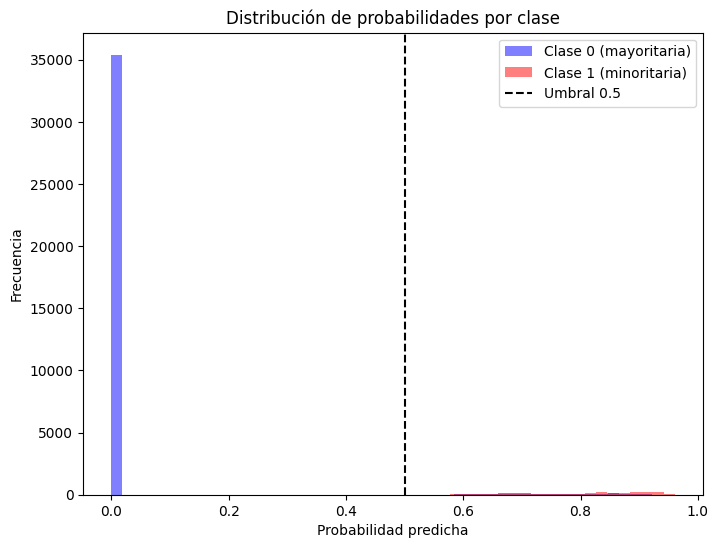

In [72]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_5_test)[np.array(all_labels_m2_5_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_5_test)[np.array(all_labels_m2_5_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

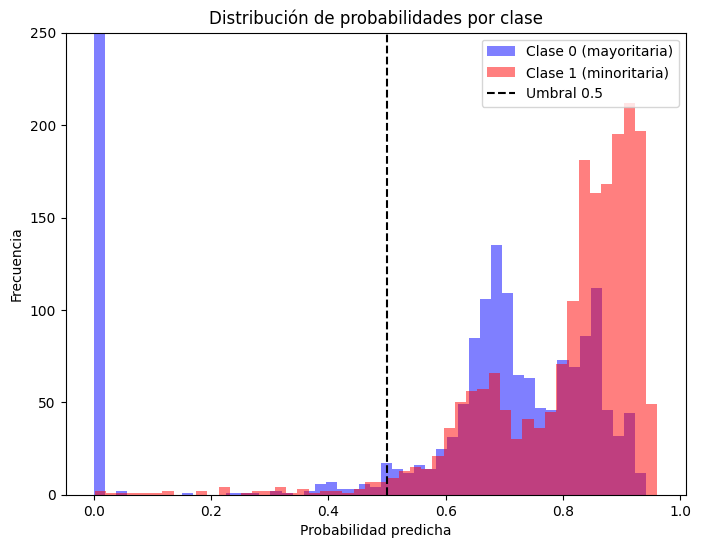

In [75]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_5_test)[np.array(all_labels_m2_5_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_5_test)[np.array(all_labels_m2_5_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,250))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-76-d96e12dd3891>:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


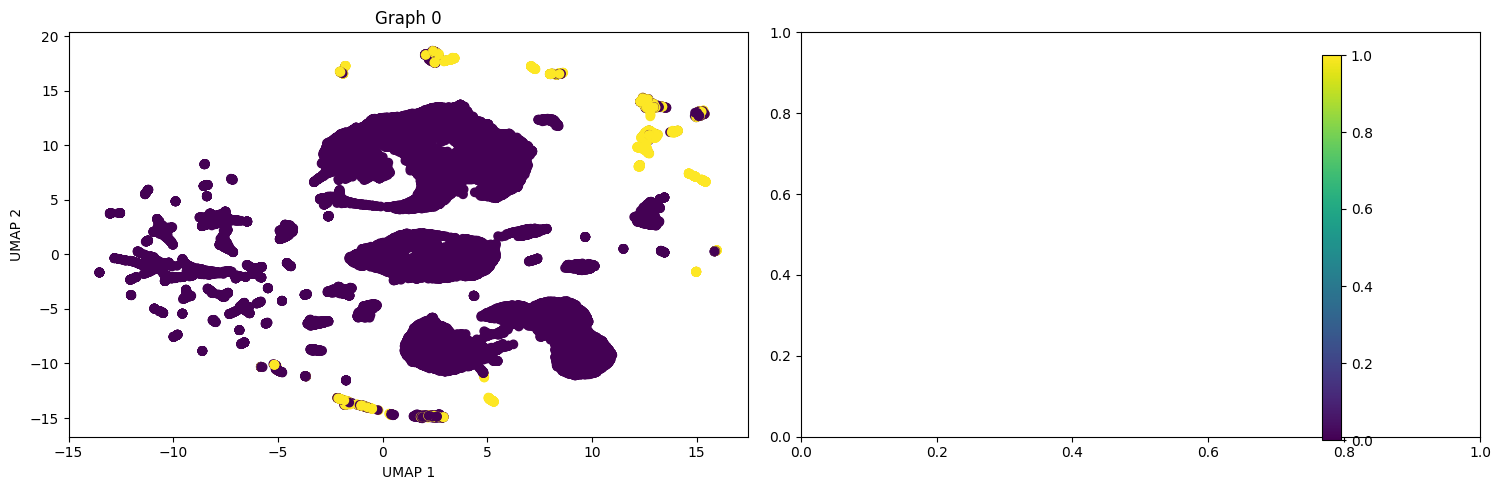

In [76]:
last_windows_for_test2 = [windows_input_test2[i][-1] for i in range(len(windows_input_test2))]

num_graphs = len(last_windows_for_test2)
rows, cols = 1,2

fig, axes = plt.subplots(rows, cols, figsize=(15,5))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_test_m2_5[i]  # Feature embeddings
    y = last_windows_for_test2[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

#### Model 2_5_1: Reusing h for training

In [77]:
model2_5_1 = EdgeClassificationModel_RNN_v3(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32)#, seq_len=4)
model2_5_1.to(device)
optimizer = torch.optim.Adam(model2_5_1.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
hidden_size_gru = 32
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

max_num_edges_train3 = max(list(set([graph.edge_index.shape[1] for i in range(21) for graph in windows_input_train3[i]])))
max_num_edges_val3 = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_val3[i]])))

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_5_1.train()
    epoch_loss = 0
    total_edges = 0
    h_0 = torch.zeros(1, max_num_edges_train3, hidden_size_gru).to(device).detach()
    for window in range(len(windows_input_train3)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train3[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train3[window][-1].y

        optimizer.zero_grad()
        out, h_n, _ = model2_5_1(data, max_num_edges_train3, h_0)
        h_n = h_n.detach()
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        h_0 = h_n

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    h_0 = torch.zeros(1, max_num_edges_val3, hidden_size_gru).to(device)
    model2_5_1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val3)):
            data_list = windows_input_val3[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val3[window][-1].y
            out, h_n, _ = model2_5_1(data, max_num_edges_val3, h_0)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
            h_0 = h_n
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2604, Val Loss: 0.1686, Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 2/15, Train Loss: 0.1101, Val Loss: 0.0951, Current LR: 0.010000, ROC-AUC: 0.8837874385541727, F1:0.6417221937467965
Epoch 3/15, Train Loss: 0.0788, Val Loss: 0.1053, Current LR: 0.010000, ROC-AUC: 0.9693496742178284, F1:0.6144151240645923
Epoch 4/15, Train Loss: 0.0726, Val Loss: 0.0820, Current LR: 0.010000, ROC-AUC: 0.9265807389539641, F1:0.693734335839599
Epoch 5/15, Train Loss: 0.0651, Val Loss: 0.0810, Current LR: 0.010000, ROC-AUC: 0.9652837421600099, F1:0.6776491540516474
Epoch 6/15, Train Loss: 0.0653, Val Loss: 0.0801, Current LR: 0.010000, ROC-AUC: 0.9624715993884351, F1:0.6972222222222222
Epoch 7/15, Train Loss: 0.0616, Val Loss: 0.0736, Current LR: 0.010000, ROC-AUC: 0.9570371588627167, F1:0.7083532219570405
Epoch 8/15, Train Loss: 0.0601, Val Loss: 0.0709, Current LR: 0.010000, ROC-AUC: 0.9620482551517034, F1:0.7054955378111789
Epoch 9/15, Train Loss: 0.0594, Val Loss: 0.072

In [78]:
# Evaluación test
model2_5_1.eval()
all_probabilities_m2_5_1_test, all_preds_m2_5_1_test, all_labels_m2_5_1_test = [], [], []
embeddings_test_m2_5_1 = []

#max_num_edges_test = max(list(set([graph.edge_index.shape[1] for graph in windows_input_test[0]])))
max_num_edges_test2 = max(list(set([graph.edge_index.shape[1] for i in range(1) for graph in windows_input_test2[i]])))
h_0 = torch.zeros(1, max_num_edges_test2, hidden_size_gru).to(device)

with torch.no_grad():
    for window in range(len(windows_input_test2)):
        data_list = windows_input_test2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test2[window][-1].y
        out, h_n, emb_t = model2_5_1(data, max_num_edges_test2, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        valid_emb = emb_t[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m2_5_1_test.extend(probabilities)
        all_preds_m2_5_1_test.extend(preds)
        all_labels_m2_5_1_test.extend(labels.cpu().numpy())
        embeddings_test_m2_5_1.append(valid_emb)
        h_0 = h_n

# Metrics
roc_auc_m2_5_1_test = roc_auc_score(all_labels_m2_5_1_test, all_preds_m2_5_1_test)
accuracy_m2_5_1_test = accuracy_score(all_labels_m2_5_1_test, all_preds_m2_5_1_test)
precision_m2_5_1_test = precision_score(all_labels_m2_5_1_test, all_preds_m2_5_1_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_5_1_test = recall_score(all_labels_m2_5_1_test, all_preds_m2_5_1_test, average='binary', zero_division=0)
f1_m2_5_1_test = f1_score(all_labels_m2_5_1_test, all_preds_m2_5_1_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_5_1_test:.4f}")
print(f"Accuracy: {accuracy_m2_5_1_test:.4f}")
print(f"Precision: {precision_m2_5_1_test:.4f}")
print(f"Recall: {recall_m2_5_1_test:.4f}")
print(f"F1: {f1_m2_5_1_test:.4f}")

# ROC-AUC: 0.9227
# Accuracy: 0.9666
# Precision: 0.6164
# Recall: 0.8739
# F1: 0.7229

ROC-AUC: 0.9259
Accuracy: 0.9634
Precision: 0.5880
Recall: 0.8843
F1: 0.7063


In [79]:
precision_1, recall_1, precision_0, recall_0, TP, FP, TN, FN = precision_recall_full(all_labels_m2_5_1_test, all_preds_m2_5_1_test)

print(f"Precisión (clase 1): {precision_1:.4f}")
print(f"Recall (clase 1): {recall_1:.4f}")
print(f"Precisión (clase 0): {precision_0:.4f}")
print(f"Recall (clase 0): {recall_0:.4f}")

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")

Precisión (clase 1): 0.5880
Recall (clase 1): 0.8843
Precisión (clase 0): 0.9938
Recall (clase 0): 0.9675
TP: 1704
FP: 1194
TN: 35564
FN: 223


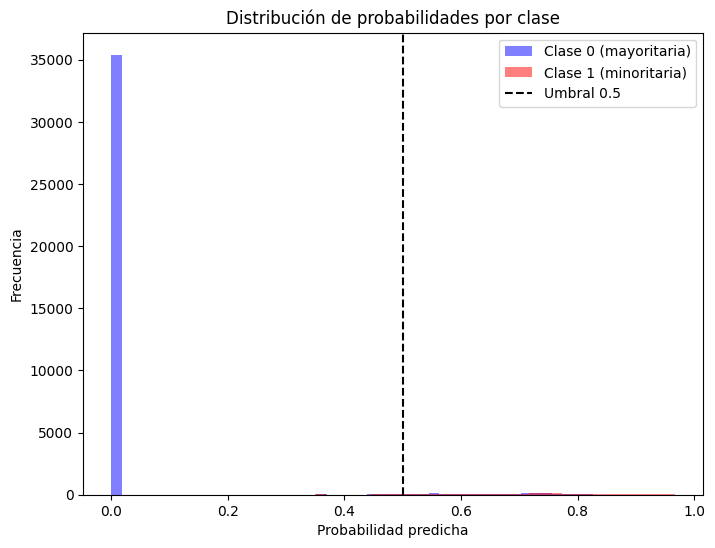

In [80]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_5_1_test)[np.array(all_labels_m2_5_1_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_5_1_test)[np.array(all_labels_m2_5_1_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

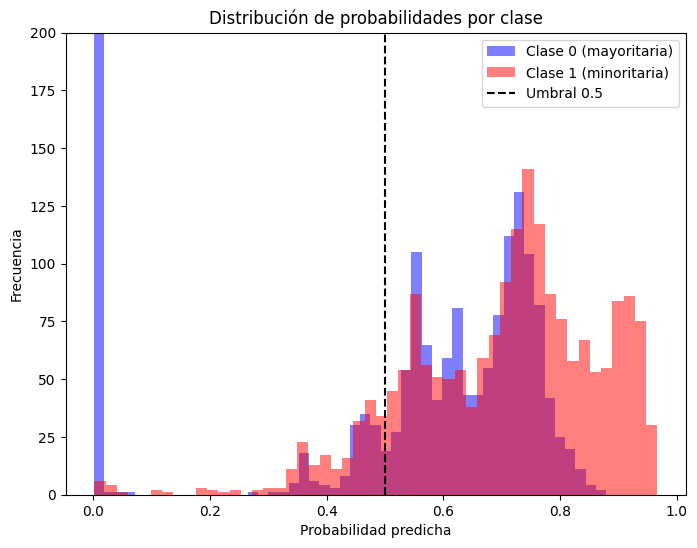

In [81]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_5_1_test)[np.array(all_labels_m2_5_1_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_5_1_test)[np.array(all_labels_m2_5_1_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,200))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-82-1cfe2aacbb7c>:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


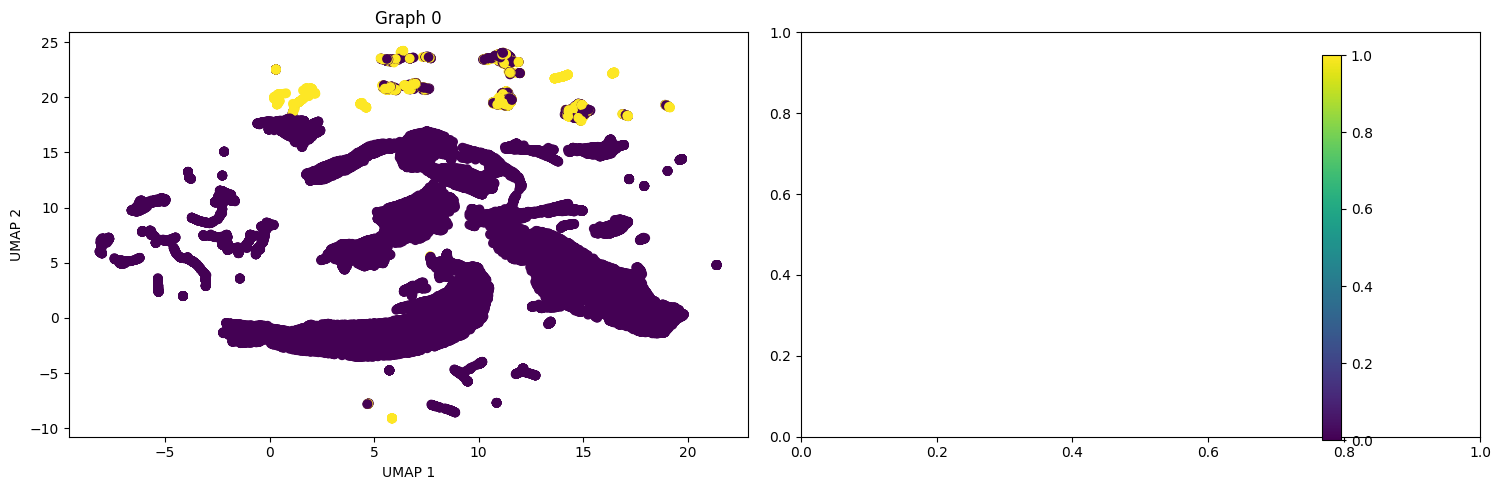

In [82]:
last_windows_for_test2 = [windows_input_test2[i][-1] for i in range(len(windows_input_test2))]

num_graphs = len(last_windows_for_test2)
rows, cols = 1,2

fig, axes = plt.subplots(rows, cols, figsize=(15,5))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_test_m2_5_1[i]  # Feature embeddings
    y = last_windows_for_test2[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

#### Comparacion sobre test: seq_len=6 - 21 windows for train, 5 for val

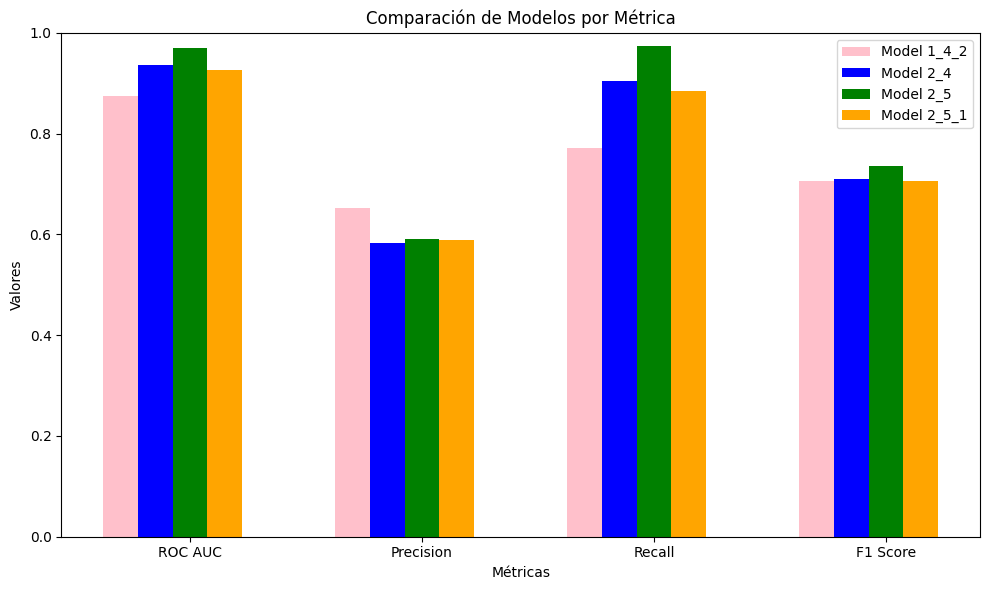

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las métricas
#metric_names = ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_names = ['ROC AUC', 'Precision', 'Recall', 'F1 Score']

# Nombres de los modelos
model_names = ['Model 1_4_2', 'Model 2_4', 'Model 2_5', 'Model 2_5_1']

# Valores de las métricas para cada modelo
roc_auc = [roc_auc_m1_4_2_test, roc_auc_m2_4_test, roc_auc_m2_5_test, roc_auc_m2_5_1_test]
accuracy = [accuracy_m1_4_2_test, accuracy_m2_4_test, accuracy_m2_5_test, accuracy_m2_5_1_test]
precision = [precision_m1_4_2_test, precision_m2_4_test, precision_m2_5_test, precision_m2_5_1_test]
recall = [recall_m1_4_2_test, recall_m2_4_test, recall_m2_5_test, recall_m2_5_1_test]
f1 = [f1_m1_4_2_test, f1_m2_4_test, f1_m2_5_test, f1_m2_5_1_test]


# Lista de métricas agrupadas
#metrics = [roc_auc, accuracy, precision, recall, f1]
metrics = [roc_auc, precision, recall, f1]

# Colores para los modelos
colors = ['pink', 'blue', 'green', 'orange']

# Crear el gráfico de barras agrupadas por métrica
x = np.arange(len(metric_names))  # Posiciones para las métricas
bar_width = 0.15  # Ancho de las barras

plt.figure(figsize=(10, 6))
for i, (model, color) in enumerate(zip(model_names, colors)):
    model_values = [metric[i] for metric in metrics]
    plt.bar(x + i * bar_width, model_values, width=bar_width, label=model, color=color)

# Personalización del gráfico
plt.xticks(x + 2 * bar_width, metric_names)
plt.xlabel('Métricas')
plt.ylabel('Valores')
plt.ylim((0,1))
plt.title('Comparación de Modelos por Métrica')
plt.legend(loc='upper right')
plt.tight_layout()

# Mostrar el gráfico
plt.show()

